In [ ]:
# Mount Google Drive to access input data
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
# ============================================================
# Import Required Libraries
# ============================================================
# os         - file path handling
# numpy      - array operations
# cv2        - image processing (erosion, dilation, edge detection)
# gdal       - geospatial raster I/O
# scipy      - morphological hit-or-miss transforms (endpoint detection)
# skimage    - feature detection, morphology, and region measurement
# pandas     - tabular data management for region properties
# matplotlib - visualization
# ============================================================

import os
import numpy as np
import cv2
from osgeo import gdal
from scipy.ndimage import binary_hit_or_miss
from skimage import feature, morphology, measure
from pandas import DataFrame
from matplotlib import pyplot as plt


In [ ]:
# Configure GDAL to raise Python exceptions on errors
# and suppress noisy console error output
gdal.UseExceptions()
gdal.PushErrorHandler('CPLQuietErrorHandler')


0

In [ ]:
# ============================================================
# Core Functions
# ============================================================

def Clip_Parent_Water_Mask(Parent_Image, Temp_Eco_File, Temp_Water_File, Temp_QC_File, Temp_Cloud_File):
    """
    Align and clip a set of ECOSTRESS scene rasters to a parent water mask extent.

    When processing multiple ECOSTRESS scenes over the same study area, a single
    'parent' water mask can serve as a common spatial reference. This function
    finds the geographic overlap between the parent mask and each scene, clips the
    scene rasters to that overlap, and places them into zero-padded arrays matching
    the parent mask dimensions.

    Parameters
    ----------
    Parent_Image     : str  - File path to the parent water mask GeoTIFF.
    Temp_Eco_File    : str  - File path to the ECOSTRESS LST GeoTIFF for the current scene.
    Temp_Water_File  : str  - File path to the scene-level water mask GeoTIFF.
    Temp_QC_File     : str  - File path to the QC band GeoTIFF.
    Temp_Cloud_File  : str  - File path to the cloud mask GeoTIFF (optional; checked with os.path.exists).

    Returns
    -------
    Eco_Aligned   : np.ndarray (float) - LST array aligned to parent extent.
    Water_Aligned : np.ndarray         - Water mask array aligned to parent extent.
    QC_Aligned    : np.ndarray (float) - QC band array aligned to parent extent.
    Cloud_Aligned : np.ndarray         - Cloud mask array aligned to parent extent (zeros if not found).
    Parent_Aligned: np.ndarray         - Raw pixel values of the parent water mask.
    """
    # Open the parent image and extract its spatial reference
    Parent_Image = gdal.Open(Parent_Image)
    ref_x_min, ref_x_res, _, ref_y_max, _, ref_y_res = Parent_Image.GetGeoTransform()
    ref_width = Parent_Image.RasterXSize
    ref_height = Parent_Image.RasterYSize
    ref_x_max = ref_x_min + ref_x_res * ref_width
    ref_y_min = ref_y_max + ref_y_res * ref_height

    # Initialize output arrays at parent dimensions (filled with zeros)
    Eco_Aligned = np.zeros((ref_height, ref_width))
    Water_Aligned = np.zeros((ref_height, ref_width))
    QC_Aligned = np.zeros((ref_height, ref_width))
    Cloud_Aligned = np.zeros((ref_height, ref_width))

    # Open the scene LST file and extract its spatial reference
    Temp_Eco = gdal.Open(Temp_Eco_File)
    temp_x_min, temp_x_res, _, temp_y_max, _, temp_y_res = Temp_Eco.GetGeoTransform()
    temp_width = Temp_Eco.RasterXSize
    temp_height = Temp_Eco.RasterYSize
    temp_x_max = temp_x_min + temp_x_res * temp_width
    temp_y_min = temp_y_max + temp_y_res * temp_height

    Temp_Water = gdal.Open(Temp_Water_File)
    Temp_QC = gdal.Open(Temp_QC_File)
    if os.path.exists(Temp_Cloud_File):
        Temp_Cloud = gdal.Open(Temp_Cloud_File)

    # Compute the geographic bounding box of the overlap region
    overlap_x_min = max(ref_x_min, temp_x_min)
    overlap_y_min = max(ref_y_min, temp_y_min)
    overlap_x_max = min(ref_x_max, temp_x_max)
    overlap_y_max = min(ref_y_max, temp_y_max)

    # Convert overlap bounds to pixel indices in the parent image grid
    TL_x_parent = int((overlap_x_min - ref_x_min) / ref_x_res)
    TL_y_parent = int((ref_y_max - overlap_y_max) / abs(ref_y_res))
    BR_x_parent = int((overlap_x_max - ref_x_min) / ref_x_res)
    BR_y_parent = int((ref_y_max - overlap_y_min) / abs(ref_y_res))

    cols_parent = BR_x_parent - TL_x_parent
    rows_parent = BR_y_parent - TL_y_parent

    if cols_parent <= 0 or rows_parent <= 0:
        raise ValueError("Images do not overlap")

    # Convert overlap bounds to pixel indices in the scene (temp) image grid
    TL_x_temp = int((overlap_x_min - temp_x_min) / temp_x_res)
    TL_y_temp = int((temp_y_max - overlap_y_max) / abs(temp_y_res))
    BR_x_temp = int((overlap_x_max - temp_x_min) / temp_x_res)
    BR_y_temp = int((temp_y_max - overlap_y_min) / abs(temp_y_res))

    cols_temp = BR_x_temp - TL_x_temp
    rows_temp = BR_y_temp - TL_y_temp

    if cols_temp <= 0 or rows_temp <= 0:
        raise ValueError("Images do not overlap")

    # Read only the overlapping pixel region from each scene raster
    # (avoids loading the full scene into memory)
    Eco_Clip   = Temp_Eco.GetRasterBand(1).ReadAsArray(TL_x_temp, TL_y_temp, cols_temp, rows_temp).astype(float)
    Water_Clip = Temp_Water.GetRasterBand(1).ReadAsArray(TL_x_temp, TL_y_temp, cols_temp, rows_temp)
    QC_Clip    = Temp_QC.GetRasterBand(1).ReadAsArray(TL_x_temp, TL_y_temp, cols_temp, rows_temp).astype(float)

    if os.path.exists(Temp_Cloud_File):
        Cloud_Clip = Temp_Cloud.GetRasterBand(1).ReadAsArray(TL_x_temp, TL_y_temp, cols_temp, rows_temp)

    # Insert clipped data into the parent-sized zero arrays at the correct position
    Eco_Aligned  [TL_y_parent:BR_y_parent, TL_x_parent:BR_x_parent] = Eco_Clip  [:rows_parent, :cols_parent]
    Water_Aligned[TL_y_parent:BR_y_parent, TL_x_parent:BR_x_parent] = Water_Clip[:rows_parent, :cols_parent]
    QC_Aligned   [TL_y_parent:BR_y_parent, TL_x_parent:BR_x_parent] = QC_Clip   [:rows_parent, :cols_parent]

    if os.path.exists(Temp_Cloud_File):
        Cloud_Aligned[TL_y_parent:BR_y_parent, TL_x_parent:BR_x_parent] = Cloud_Clip[:rows_parent, :cols_parent]

    Parent_Aligned = Parent_Image.ReadAsArray()

    # Close all GDAL datasets
    Parent_Image = None
    Temp_Eco = None
    Temp_Water = None
    Temp_QC = None
    Temp_Cloud = None

    return Eco_Aligned.astype(float), Water_Aligned, QC_Aligned.astype(float), Cloud_Aligned, Parent_Aligned


def Best_Line_Eco(Line_Number, Ref_img, Og_Ref_img, Img_to_Clip, expand, step):
    """
    Extract a spatially bounded sub-region of an image centered on a target shoreline segment.

    This function supports two modes (controlled by 'step'):
      - step=0: Operates on all labeled regions that exceed a minimum area threshold,
                returning the bounding box that spans all qualifying regions.
      - step=1: Operates on a single labeled region identified by Line_Number,
                returning the bounding box for that specific region.

    In both cases the bounding box is expanded by 'expand' pixels on all sides to
    provide context for subsequent shift-matching operations.

    Parameters
    ----------
    Line_Number  : int        - Index into the region table (used in step=1 mode).
    Ref_img      : np.ndarray - Labeled image used for region bounding-box calculation.
    Og_Ref_img   : np.ndarray - Original (non-labeled) shoreline binary image (used in step=0).
    Img_to_Clip  : np.ndarray - Secondary image to clip to the same bounding box (e.g., LST edges).
    expand       : int/float  - Padding (in pixels) to add around the bounding box.
    step         : int        - Mode selector: 0 = all qualifying lines, 1 = single line.

    Returns
    -------
    Clipped_Reference : np.ndarray - Clipped shoreline reference within the bounding box.
    Clipped_ITC       : np.ndarray - Clipped version of Img_to_Clip within the bounding box.
    Clip_Values       : tuple      - (row_start, row_end, col_start, col_end) bounding box indices.
    Col_length        : float      - Column extent of the identified region.
    Row_length        : float      - Row extent of the identified region.
    maxlines          : int        - Zero-based index of the selected region label.
    """
    expand = int(expand)

    # Pad images to avoid boundary artifacts when the region is near the edge
    Reference_Img = np.pad(Ref_img, ((expand, expand), (expand, expand)), mode='constant', constant_values=0)
    Image_to_Clip = np.pad(Img_to_Clip, ((expand, expand), (expand, expand)), mode='constant', constant_values=0)

    # Compute bounding box statistics for all labeled regions
    stats = measure.regionprops_table(Reference_Img, properties=('label', 'bbox', 'bbox_area'))
    Line_Box_Boundaries = DataFrame(stats)
    Line_Box_Boundaries = Line_Box_Boundaries.sort_values('bbox_area', ascending=False)

    # Keep only regions with bounding box area > 1000 pixels (filters noise)
    Filter = (Line_Box_Boundaries['bbox_area'] > 1000).to_list()
    Binary_Filter = [1 if x else 0 for x in Filter]

    Labels = Line_Box_Boundaries['label'].to_list()
    maxlines = Labels[Line_Number]

    if step == 0:
        # step=0: use all regions that pass the area filter
        Labels = np.multiply(Binary_Filter, Line_Box_Boundaries['label'].to_list())
        Mask = np.isin(Reference_Img, test_elements=Labels)
    else:
        # step=1: use only the single region at Line_Number
        Mask = np.isin(Reference_Img, test_elements=maxlines)

    maxlines = maxlines - 1  # Convert to zero-based index

    if step == 0:
        # Compute a bounding box that spans all qualifying regions
        Pad_Col_S = int(abs(Line_Box_Boundaries['bbox-0'].min() - expand))
        Pad_Col_E = int(Line_Box_Boundaries['bbox-2'].max() + expand)
        Pad_Row_S = int(abs(Line_Box_Boundaries['bbox-1'].min() - expand))
        Pad_Row_E = int(Line_Box_Boundaries['bbox-3'].max() + expand)

        Original_Shoreline = np.pad(Og_Ref_img, ((expand, expand), (expand, expand)), mode='constant', constant_values=0)

        Mask = Mask[Pad_Col_S:Pad_Col_E, Pad_Row_S:Pad_Row_E]
        Clipped_Shoreline = Original_Shoreline[Pad_Col_S:Pad_Col_E, Pad_Row_S:Pad_Row_E]
        Clipped_Reference = Clipped_Shoreline * Mask
        Clipped_ITC = Image_to_Clip[Pad_Col_S:Pad_Col_E, Pad_Row_S:Pad_Row_E]
        Clip_Values = (Pad_Col_S, Pad_Col_E, Pad_Row_S, Pad_Row_E)

    if step == 1:
        # Compute a bounding box for the single selected region
        Pad_Col_S = int(abs(Line_Box_Boundaries.at[maxlines, 'bbox-0'] - expand))
        Pad_Col_E = int(Line_Box_Boundaries.at[maxlines, 'bbox-2'] + expand)
        Pad_Row_S = int(abs(Line_Box_Boundaries.at[maxlines, 'bbox-1'] - expand))
        Pad_Row_E = int(Line_Box_Boundaries.at[maxlines, 'bbox-3'] + expand)

        Clipped_Reference = np.clip(Mask[Pad_Col_S:Pad_Col_E, Pad_Row_S:Pad_Row_E], a_min=0, a_max=1)
        Clipped_ITC = np.clip(Image_to_Clip[Pad_Col_S:Pad_Col_E, Pad_Row_S:Pad_Row_E], a_min=0, a_max=1)
        Clip_Values = (Pad_Col_S, Pad_Col_E, Pad_Row_S, Pad_Row_E)

    Col_length = Line_Box_Boundaries.at[maxlines, 'bbox-1']
    Row_length = Line_Box_Boundaries.at[maxlines, 'bbox-3']

    return Clipped_Reference, Clipped_ITC, Clip_Values, Col_length, Row_length, maxlines


def Sorted_Longest_Lines(img):
    """
    Label connected components in a binary image and return them sorted by pixel count.

    Parameters
    ----------
    img : np.ndarray - Binary image (values 0/1) to label.

    Returns
    -------
    Sorted_Table       : DataFrame   - Region properties table with 'Line_Length' column, sorted descending.
    Labeled_Img        : np.ndarray  - Integer-labeled connected component image.
    """
    Labeled_Img = measure.label(img, connectivity=2)
    Labeled_Table = measure.regionprops_table(Labeled_Img, properties=('label', 'bbox', 'bbox_area'))
    Labeled_Table = DataFrame(Labeled_Table)

    # Count actual non-zero pixels per label (more accurate than bbox_area for thin lines)
    Line_Lengths = []
    for i in range(1, Labeled_Table.shape[0] + 1):
        count = np.count_nonzero(Labeled_Img == i)
        Line_Lengths.append(count)

    Labeled_Table.insert(6, "Line_Length", Line_Lengths, True)
    Sorted_Table = Labeled_Table.sort_values('Line_Length', ascending=False)

    return Sorted_Table, Labeled_Img


def End_Points(img):
    """
    Skeletonize a binary image and detect its endpoints via hit-or-miss transforms.

    Endpoints are pixels connected to exactly one other skeleton pixel (i.e., the
    tips of line features). Eight directional structuring elements are tested to
    capture all possible endpoint orientations.

    For circular/closed contours that have no endpoints, the function falls back
    to returning all skeleton pixels as candidate start points.

    Parameters
    ----------
    img : np.ndarray - Binary image of a single shoreline or edge segment.

    Returns
    -------
    Skeleton_ECOSTRESS : np.ndarray      - Skeletonized version of the input image.
    EndP_Locations     : list of tuples  - (row, col) coordinates of detected endpoints.
    """
    Skeleton_ECOSTRESS = (morphology.skeletonize(img)).astype(np.uint8)

    # Eight hit-or-miss structuring elements covering all 8 directions from center pixel
    directions = [
        np.array([[1,0,0],[0,1,0],[0,0,0]]).astype(np.uint8),
        np.array([[0,1,0],[0,1,0],[0,0,0]]).astype(np.uint8),
        np.array([[0,0,1],[0,1,0],[0,0,0]]).astype(np.uint8),
        np.array([[0,0,0],[1,1,0],[0,0,0]]).astype(np.uint8),
        np.array([[0,0,0],[0,1,1],[0,0,0]]).astype(np.uint8),
        np.array([[0,0,0],[0,1,0],[1,0,0]]).astype(np.uint8),
        np.array([[0,0,0],[0,1,0],[0,1,0]]).astype(np.uint8),
        np.array([[0,0,0],[0,1,0],[0,0,1]]).astype(np.uint8)
    ]

    Combined_Results = sum(
        binary_hit_or_miss(Skeleton_ECOSTRESS, structure1=EndPoint_Orientation).astype(int)
        for EndPoint_Orientation in directions
    )

    endpoint_locations = np.where(Combined_Results == 1)
    EndP_Locations = list(zip(endpoint_locations[0], endpoint_locations[1]))  # (row, col) order

    # Fallback for closed contours with no endpoints
    if len(EndP_Locations) == 0:
        Every_ones_Location = np.where(Skeleton_ECOSTRESS == 1)
        Total_Location = list(zip(Every_ones_Location[0], Every_ones_Location[1]))
        EndP_Locations = Total_Location[0]

    return Skeleton_ECOSTRESS, EndP_Locations


def MatchingOverlay(Eco, Water, expand, endpoints):
    """
    Generate candidate pixel shifts by matching an ECOSTRESS edge endpoint to
    nearby water mask pixels, then evaluate each shift.

    A search window of ±expand pixels around the ECOSTRESS endpoint is used to
    enumerate candidate shifts. Each candidate is passed to Matching_Shift, which
    finds the shift that maximizes overlap between the shifted ECOSTRESS edge and
    the water mask shoreline.

    Parameters
    ----------
    Eco       : np.ndarray         - Binary ECOSTRESS skeleton/edge image.
    Water     : np.ndarray         - Binary water mask shoreline image.
    expand    : int                - Pixel search radius around the endpoint.
    endpoints : list or tuple      - Endpoint coordinate(s) from End_Points().

    Returns
    -------
    X_Shift         : int   - Best horizontal pixel shift.
    Y_Shift         : int   - Best vertical pixel shift.
    Eco_Ratio       : float - Fraction of ECOSTRESS pixels overlapping the water mask at best shift.
    Overlapped_Twos : np.ndarray - Combined image at the best shift (pixel value=2 indicates overlap).
    """
    # Extract endpoint coordinates (handle both list-of-tuples and single tuple)
    if type(endpoints) is list:
        yend_Eco = endpoints[0][0]
        xend_Eco = endpoints[0][1]
    if type(endpoints) is tuple:
        yend_Eco = endpoints[0]
        xend_Eco = endpoints[1]

    Water_Coordinates = np.argwhere(Water == 1)
    xs = []
    ys = []
    for i in range(0, len(Water_Coordinates)):
        ys.append(Water_Coordinates[i][0])
        xs.append(Water_Coordinates[i][1])

    # Boolean mask: which water pixels fall within the search window
    positions = (xs <= (xend_Eco + expand)) & (xs >= (xend_Eco - expand)) & \
                (ys <= (yend_Eco + expand)) & (ys >= (yend_Eco - expand))

    # Convert to relative (dx, dy) shift coordinates
    Shift_Coordinates = np.column_stack((positions * (xs * positions - xend_Eco),
                                         positions * (ys * positions - yend_Eco)))

    # Remove rows where both values are zero (no shift candidate)
    mask = np.count_nonzero(Shift_Coordinates, axis=1) == Shift_Coordinates.shape[1] - 2
    filtered_arr = Shift_Coordinates[~mask]
    filtered_arr = np.vstack((filtered_arr, [0, 0]))  # Always include the no-shift option

    [X_Shift, Y_Shift, Eco_Ratio, _, Overlapped_Twos] = Matching_Shift(filtered_arr, Eco, Water)

    return X_Shift, Y_Shift, Eco_Ratio, Overlapped_Twos


def Matching_Shift(Shift_Coordinates, Eco, Water):
    """
    Evaluate all candidate pixel shifts and return the one that maximizes
    overlap between the shifted ECOSTRESS edge and the water mask shoreline.

    For each (dx, dy) pair in Shift_Coordinates, the ECOSTRESS binary image
    is rolled (cyclically shifted) and added to the water mask. Pixels with
    value 2 in the sum indicate co-located edge pixels — the more of these,
    the better the geolocation correction.

    Parameters
    ----------
    Shift_Coordinates : np.ndarray - Array of (dx, dy) candidate shifts.
    Eco               : np.ndarray - Binary ECOSTRESS skeleton/edge image.
    Water             : np.ndarray - Binary water mask shoreline image.

    Returns
    -------
    X_Shift        : int         - Optimal horizontal pixel shift.
    Y_Shift        : int         - Optimal vertical pixel shift.
    Eco_Ratio      : float       - Overlap fraction (overlapping pixels / total ECOSTRESS pixels).
    Connected_Twos : np.ndarray  - Combined image at optimal shift.
    Best_Position  : int         - Count of co-located pixels at the optimal shift.
    """
    Best_Position = 0
    Best_Index = 0
    Eco_Ratio = 0
    Connected_Twos = []

    for i in range(len(Shift_Coordinates)):
        Shifted_Image = np.roll(Eco, (Shift_Coordinates[i]), axis=(1, 0))
        New_Combined = Shifted_Image + Water

        # Count pixels where both ECOSTRESS and water mask are present (value=2)
        New_Twos = np.count_nonzero(New_Combined == 2)

        if New_Twos > Best_Position:
            Best_Position = New_Twos
            Best_Index = i
            Eco_Ratio = New_Twos / np.count_nonzero(Eco == 1)
            Connected_Twos = New_Combined

    # If no shift improves overlap, default to zero shift
    if Best_Position == 0:
        X_Shift = 0
        Y_Shift = 0
        Eco_Ratio = 0
        Connected_Twos = Eco + Water
    else:
        Y_Shift = Shift_Coordinates[Best_Index, 1]
        X_Shift = Shift_Coordinates[Best_Index, 0]

    return X_Shift, Y_Shift, Eco_Ratio, Connected_Twos, Best_Position


Shift correction will be ran for ECO_L2T_LSTE.002_LST_doy2023205200541_aid0001_16N.tif using personalized water mask


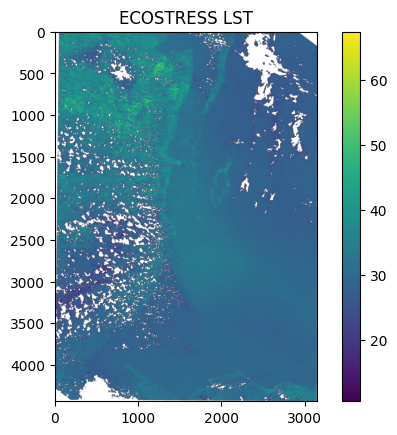

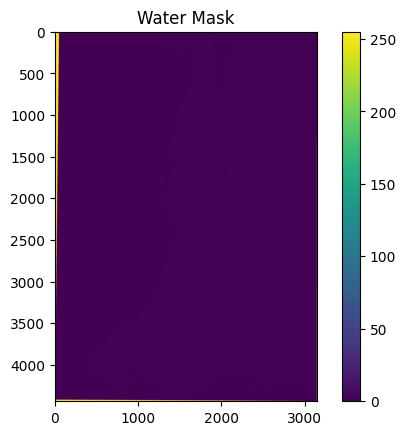

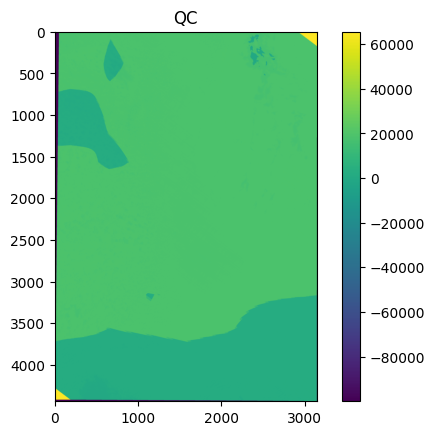

In [ ]:
## ============================================================
## User Configuration: Input Paths and Filenames
## ============================================================
## Update the folder paths and LST filename below to point to
## your own Google Drive directory structure before running.
## ============================================================

# --- Input folder paths ---
# Each variable should point to the folder containing the
# corresponding ECOSTRESS product GeoTIFFs.
LST_Folder   = "/content/drive/MyDrive/<YOUR_PROJECT_FOLDER>/ECOSTRESS Tifs/QCd_LST"
Water_Folder = "/content/drive/MyDrive/<YOUR_PROJECT_FOLDER>/ECOSTRESS Tifs/Water"
QC_Folder    = "/content/drive/MyDrive/<YOUR_PROJECT_FOLDER>/ECOSTRESS Tifs/QC"
Cloud_Folder = "/content/drive/MyDrive/<YOUR_PROJECT_FOLDER>/ECOSTRESS Tifs/Cloud"

# --- Target LST filename ---
# Set this to the LST GeoTIFF you want to geolocation-correct.
# The associated QC, cloud mask, and water mask filenames are
# derived automatically by string replacement below.
lst_name = 'ECO_L2T_LSTE.002_LST_doy2023205200541_aid0001_16N.tif'

# --- Optional parent water mask ---
# If set to None, the scene-level water mask is used directly.
# To use a larger parent water mask as a spatial reference,
# set this to the full file path of that parent GeoTIFF.
Parent_Water_Mask = None

# --- Derive associated filenames by replacing the '_LST_' token ---
qc_name = lst_name.replace('_LST_', '_QC_')
c_name  = lst_name.replace('_LST_', '_cloud_mask_')
wm_name = lst_name.replace('_LST_', '_water_')

# Handle alternate water mask naming convention (_water_mask_ vs _water_)
wm_check = os.path.join(Water_Folder, wm_name)
if not os.path.exists(wm_check):
    wm_name = lst_name.replace('_LST_', '_water_mask_')

## --- Construct full file paths ---
EcoFile   = os.path.join(LST_Folder,   lst_name)
QCFile    = os.path.join(QC_Folder,    qc_name)
WaterFile = os.path.join(Water_Folder, wm_name)
CloudFile = os.path.join(Cloud_Folder, c_name)

## --- Load rasters ---
# If no valid Parent_Water_Mask is provided, open the scene rasters directly.
# Otherwise, clip all rasters to the parent water mask extent.
if Parent_Water_Mask is None or not os.path.exists(Parent_Water_Mask):
    Eco   = gdal.Open(EcoFile).ReadAsArray().astype(float)
    Water = gdal.Open(WaterFile).ReadAsArray()
    QC    = gdal.Open(QCFile).ReadAsArray().astype(float)

    Cloud = None
    if os.path.exists(CloudFile):
        Cloud = gdal.Open(CloudFile).ReadAsArray()

    Eco[Eco == 0] = np.nan  # Replace fill value (0) with NaN for cleaner visualization
    print('Shift correction will be run for', lst_name, 'using scene-level water mask')

else:
    Eco, _, QC, Cloud, Water = Clip_Parent_Water_Mask(Parent_Water_Mask, EcoFile, WaterFile, QCFile, CloudFile)
    Eco[Eco == 0] = np.nan
    print('Shift correction will be run for', lst_name, 'using parent water mask')

# --- Quick visualization of loaded rasters ---
plt.imshow(Eco, cmap='viridis')
plt.colorbar()
plt.title('ECOSTRESS LST')
plt.show()

plt.imshow(Water, cmap='viridis')
plt.colorbar()
plt.title('Water Mask')
plt.show()

plt.imshow(QC, cmap='viridis')
plt.colorbar()
plt.title('QC')
plt.show()


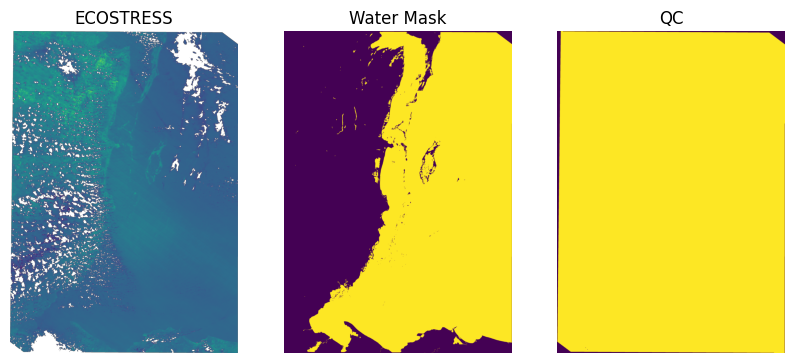

Edges along the border of the image have been removed in the "Water Mask Edges" image


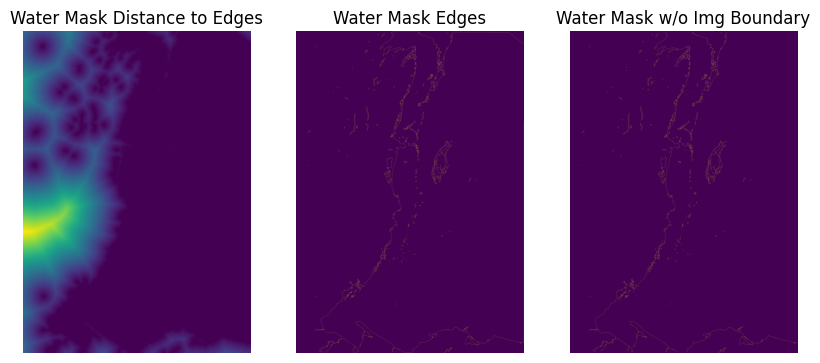

In [ ]:
## ============================================================
## Step 1: Derive Acceptable QC Pixels and Extract Water Mask Shoreline
## ============================================================
## The QC band contains fill/invalid flags. We create a binary mask of
## valid pixels, then erode its edges to avoid including image boundary
## artifacts in the shoreline detection step.
##
## QC flag values excluded:
##   -99999 : fill / no data
##    65535 : saturated or otherwise invalid
##        0 : background / unprocessed
## ============================================================

# Binary mask: 1 where QC indicates valid LST data
Accetable_Values_Area = ((QC != -99999) & (QC != 65535) & (QC != 0)).astype(np.uint8)

# Erode valid-data mask with a 6x6 elliptical kernel to trim image boundary pixels
# This prevents the image edge from being misidentified as a shoreline
Erase = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (6, 6)).astype(np.uint8)
Eroded_QC = cv2.erode(src=Accetable_Values_Area, kernel=Erase).astype(np.uint8)

## ============================================================
## Step 2: Extract the Shoreline (Inner Edge of the Water Mask)
## ============================================================
## We want a 1-pixel-wide shoreline tracing the land/water boundary.
## This is done by:
##   1. Inverting the water mask
##   2. Running a distance transform on the inverted mask
##   3. Selecting pixels exactly 1 unit from the nearest water pixel
##   4. Applying the eroded QC mask to remove boundary artifacts
## ============================================================

# Replace water mask nodata (255) with 0 (background, not water)
Water[Water == 255] = 0

# Invert water mask so land=255, water=0 — needed for distance transform
Inverse_Water = cv2.bitwise_not((Water * 255)).astype(np.uint8)
Inverse_Water_255 = (Inverse_Water * 255).astype(np.uint8)

# Euclidean distance transform: each pixel = distance to nearest water pixel
Inverse_dist_transform_water = cv2.distanceTransform(
    src=Inverse_Water_255, distanceType=cv2.DIST_L2, maskSize=5
)

# Select pixels at exactly distance=1 (the immediate land-side shoreline boundary)
Distance_to_Edge = Inverse_dist_transform_water == 1

# Apply eroded QC mask to remove edge pixels caused by the image boundary
Inverse_Accetable_Values_Area = (Distance_to_Edge).astype(np.uint8) * Eroded_QC

# Sanity check: confirm shoreline pixels exist
test1 = np.unique(Inverse_Accetable_Values_Area)
test2 = list(test1[1:])  # Exclude 0 (background)

## --- Visualize intermediate results ---
fig, axs = plt.subplots(1, 3, figsize=(10, 10))
axs[0].imshow(Eco);       axs[0].set_title('ECOSTRESS');   axs[0].axis('off')
axs[1].imshow(Water);     axs[1].set_title('Water Mask');  axs[1].axis('off')
axs[2].imshow(Eroded_QC); axs[2].set_title('QC (Eroded)'); axs[2].axis('off')
plt.show()

print('Edges along the border of the image have been removed in the "Water Mask Edges" image')

fig, axs = plt.subplots(1, 3, figsize=(10, 10))
axs[0].imshow(Inverse_dist_transform_water); axs[0].set_title('Distance to Water Edge'); axs[0].axis('off')
axs[1].imshow((Inverse_dist_transform_water == 1)); axs[1].set_title('Water Mask Edges'); axs[1].axis('off')
axs[2].imshow(Inverse_Accetable_Values_Area); axs[2].set_title('Shoreline (No Img Boundary)'); axs[2].axis('off')
plt.show()


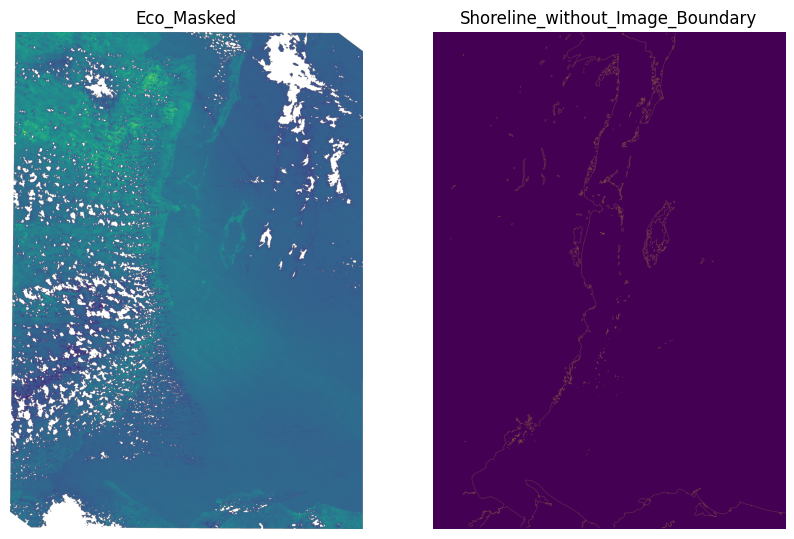

In [ ]:
## ============================================================
## Step 3: Apply Cloud Mask to ECOSTRESS and Water Mask Shoreline
## ============================================================
## Cloud-contaminated pixels produce unreliable thermal edges and
## should be excluded from geolocation matching.
##
## Two buffer distances are applied:
##   dist  =   5 px: Small cloud buffer applied to the LST image.
##             Keeps pixels very close to cloud edges for edge detection.
##   dist2 = 100 px: Large cloud buffer applied to the water mask shoreline.
##             Removes shoreline segments near clouds to avoid matching
##             thermally confused edges.
## ============================================================

if os.path.exists(CloudFile):
    # Convert cloud mask to uint8 (0=clear, 255=cloudy) for distance transform
    Cloud_255 = (Cloud * 255).astype(np.uint8)

    # Euclidean distance transform: each pixel = distance to nearest cloud pixel
    dist_transform = cv2.distanceTransform(Cloud_255, cv2.DIST_L2, 5)

    # --- Small buffer (5 px): mask LST pixels inside cloud cores ---
    dist = 5
    _, Small_Cloud_Edge_Dilate = cv2.threshold(dist_transform, dist, 255, cv2.THRESH_BINARY)
    Small_Cloud_Edge_Dilate = cv2.bitwise_not(Small_Cloud_Edge_Dilate.astype(np.uint8))  # Invert: 255=clear

    Eco_Masked = Eco * Small_Cloud_Edge_Dilate
    Eco_Masked[Eco_Masked == 0] = np.nan  # Restore NaN for masked/invalid pixels

    # --- Large buffer (100 px): remove shoreline near clouds ---
    dist2 = 100
    _, Cloud_Edge_Eroded = cv2.threshold(dist_transform, dist2, 255, cv2.THRESH_BINARY)
    Cloud_Edge_Eroded = cv2.bitwise_not(Cloud_Edge_Eroded.astype(np.uint8)) / 255  # Normalize to 0–1

    Shoreline_without_Image_Boundary = Inverse_Accetable_Values_Area * Cloud_Edge_Eroded
    Shoreline_without_Image_Boundary[Shoreline_without_Image_Boundary == 0] = 0  # Ensure clean zeros

else:
    # No cloud mask available — use original LST and shoreline as-is
    Eco_Masked = Eco
    Eco_Masked[Eco_Masked == 0] = np.nan
    Shoreline_without_Image_Boundary = Inverse_Accetable_Values_Area

## --- Visualize results ---
fig, axs = plt.subplots(1, 2, figsize=(10, 10))
axs[0].imshow(Eco_Masked); axs[0].set_title('Cloud-Masked LST'); axs[0].axis('off')
axs[1].imshow(Shoreline_without_Image_Boundary); axs[1].set_title('Shoreline (Cloud-Buffered)'); axs[1].axis('off')
plt.show()


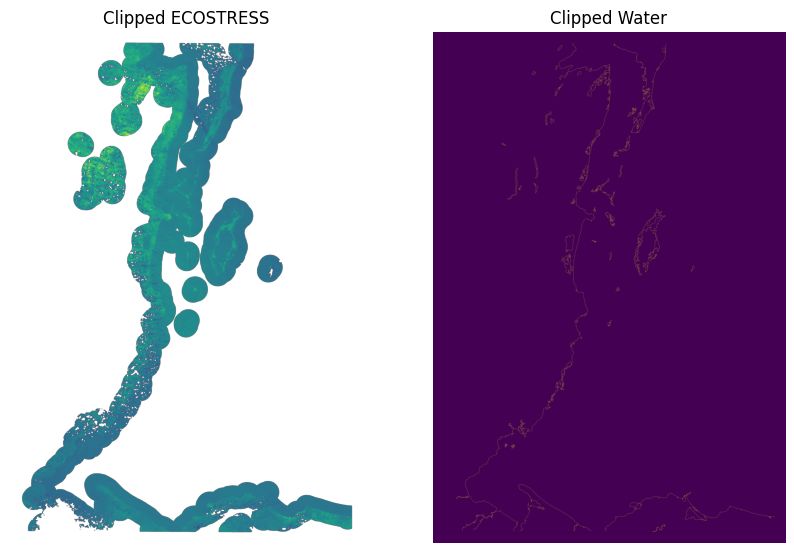

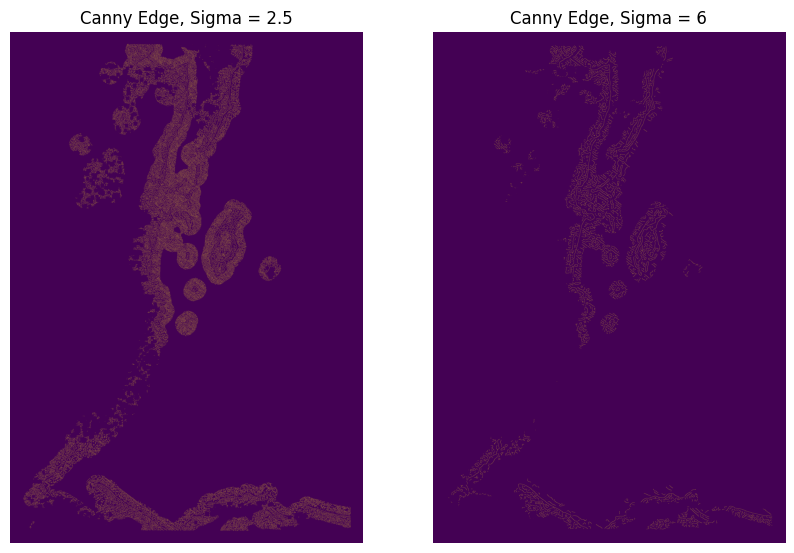

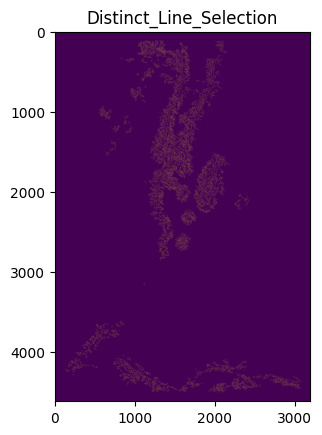

In [ ]:
## ============================================================
## Step 4: Identify the Dominant Shoreline and Detect LST Edges
## ============================================================
## Strategy:
##   1. Slightly dilate the shoreline to connect nearby fragments,
##      then label connected components.
##   2. Clip both the water mask shoreline and LST image to the
##      bounding box of the longest/dominant shoreline segment.
##   3. Apply a 100-pixel water buffer to the LST to restrict edge
##      detection to regions plausibly near the shoreline.
##   4. Run Canny edge detection at two sigma values:
##       - sigma=2.5: fine-grained edges (higher accuracy)
##       - sigma=6.0: coarse edges (simpler structure for matching)
##      Keeping only edges that appear in both filters retains
##      thermally distinct shoreline edges while discarding noise.
## ============================================================

# Dilate shoreline to bridge small gaps before connected-component labeling
Connecting_Shoreline = morphology.binary_dilation(Shoreline_without_Image_Boundary).astype(np.uint8)

# Label connected shoreline components (8-connectivity)
_, Mapped_Lines = cv2.connectedComponents(Connecting_Shoreline, connectivity=8)

# Clip both arrays to the bounding box of the largest shoreline region
[Clip_Water, Clip_Eco, _, _, _, _] = Best_Line_Eco(
    0, Mapped_Lines, Shoreline_without_Image_Boundary, Eco_Masked, 100, 0
)

# Label clipped water mask components and compute their areas
_, Mapped_Lines2, stats, _ = cv2.connectedComponentsWithStats(
    Clip_Water.astype(np.uint8), connectivity=8
)
Shore_lengths = stats[:, cv2.CC_STAT_AREA]
sorted_indecies = np.argsort(-Shore_lengths)  # Descending order by area

# Placeholder array used as a dummy argument in Best_Line_Eco step=1 calls
Blank = np.array([[0, 0], [0, 0]]).astype(np.uint8)

Main_Matching_Stats = []
Clip_Eco[Clip_Eco == 0] = np.nan

# --- Apply 100-pixel water buffer to constrain LST edge detection area ---
# Only LST pixels within 100 px of the water mask are candidates for shift matching
Water_Buffer = morphology.isotropic_dilation(Clip_Water, radius=100)
Clip_Eco[~Water_Buffer] = np.nan

# --- Canny edge detection at two smoothing levels ---
# sigma=2.5 preserves fine spatial detail; sigma=6 captures dominant thermal gradients
Initial_Canny   = feature.canny(Clip_Eco, sigma=2.5)
High_Blur_Canny = feature.canny(Clip_Eco, sigma=6)

# Label fine-scale edges and retain only those that overlap with coarse-scale edges
# This intersection step removes spurious thin features not visible at larger scales
Labeled_Edges     = measure.label(Initial_Canny, connectivity=2)
Overlapping_Lines = Labeled_Edges * High_Blur_Canny
Distinct_Line_Nums = list(np.unique(Overlapping_Lines)[1:])  # Exclude background (0)
Distinct_Line_Selection = np.isin(Labeled_Edges, test_elements=Distinct_Line_Nums)

## --- Visualize intermediate outputs ---
fig, axs = plt.subplots(1, 2, figsize=(10, 10))
axs[0].imshow(Clip_Eco);   axs[0].set_title('Clipped ECOSTRESS LST'); axs[0].axis('off')
axs[1].imshow(Clip_Water); axs[1].set_title('Clipped Water Mask');    axs[1].axis('off')
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 10))
axs[0].imshow(Initial_Canny);   axs[0].set_title('Canny Edge (sigma=2.5)'); axs[0].axis('off')
axs[1].imshow(High_Blur_Canny); axs[1].set_title('Canny Edge (sigma=6)');   axs[1].axis('off')
plt.show()

plt.figure()
plt.imshow(Distinct_Line_Selection)
plt.title('Filtered Distinct LST Edges')
plt.show()


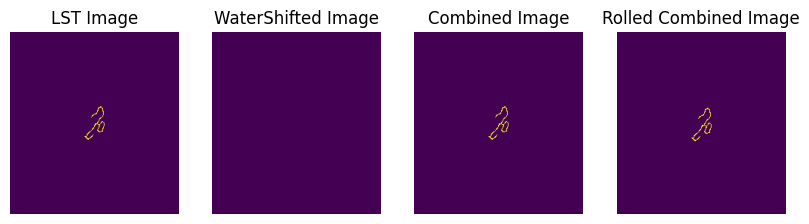

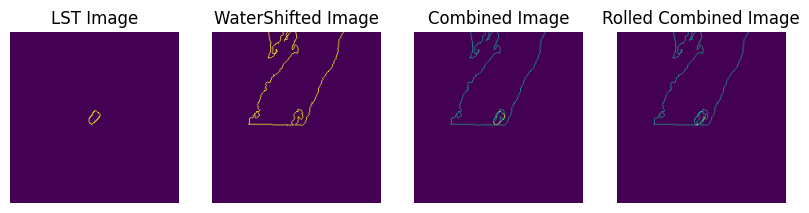

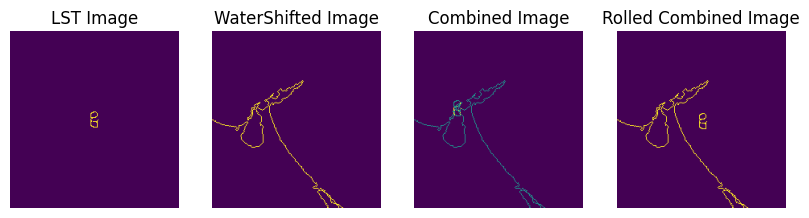

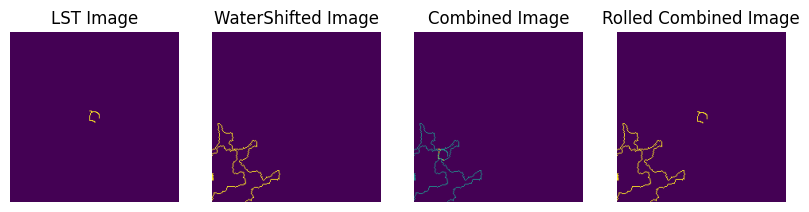

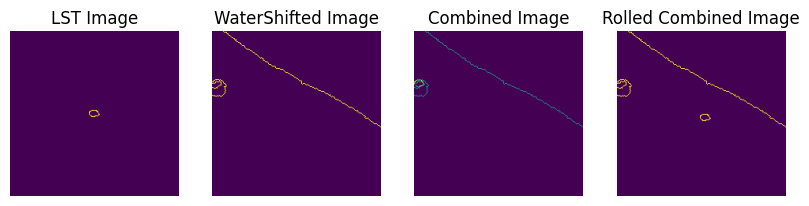

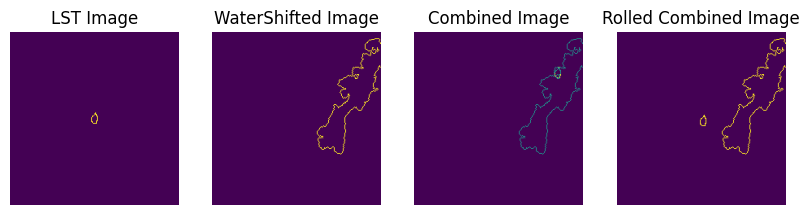

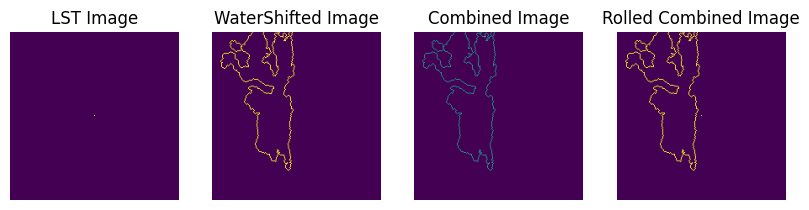

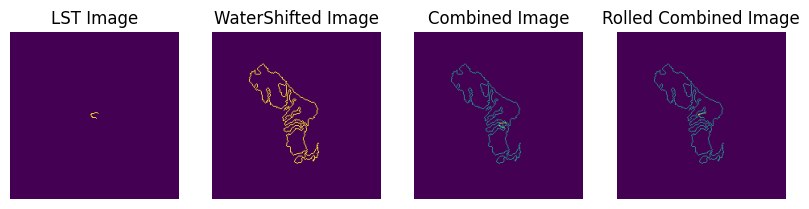

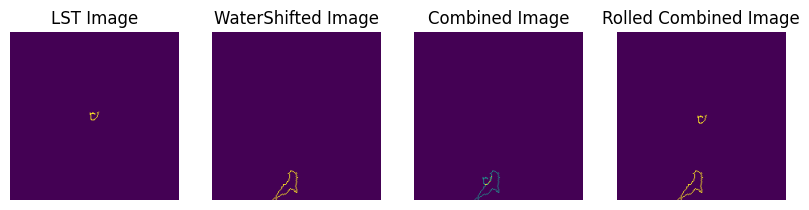

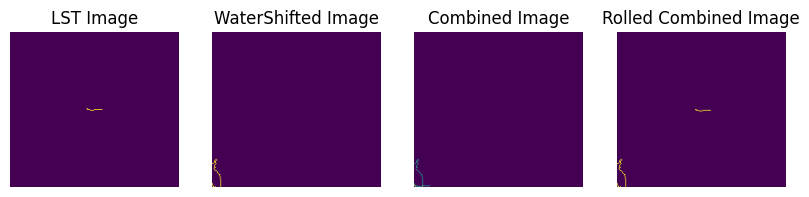

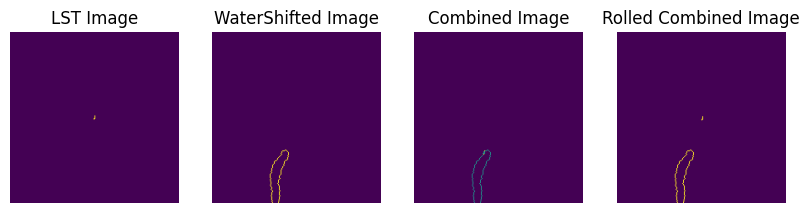

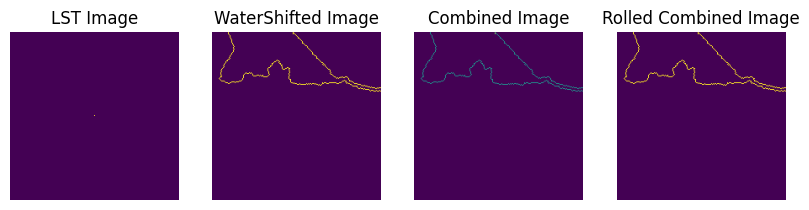

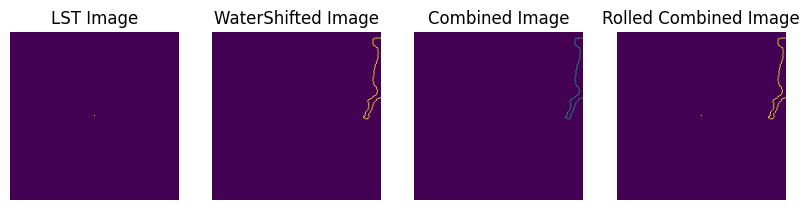

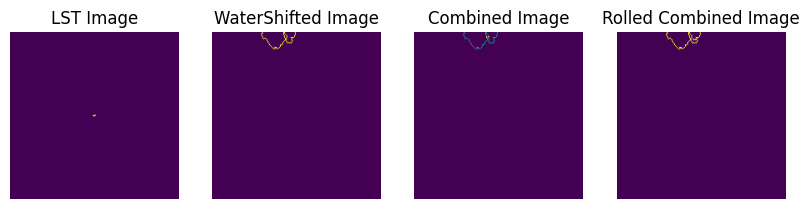

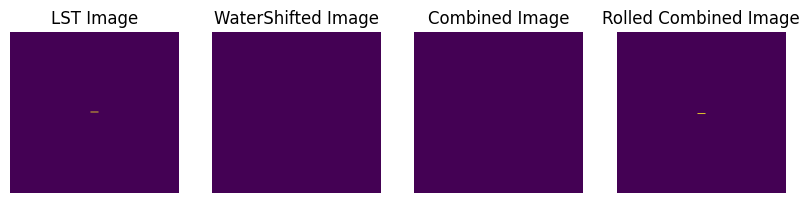

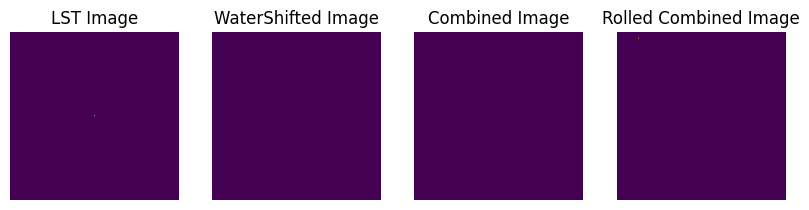

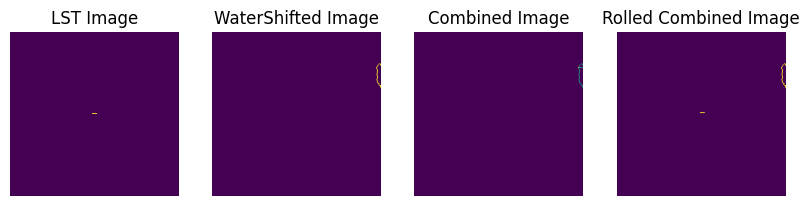

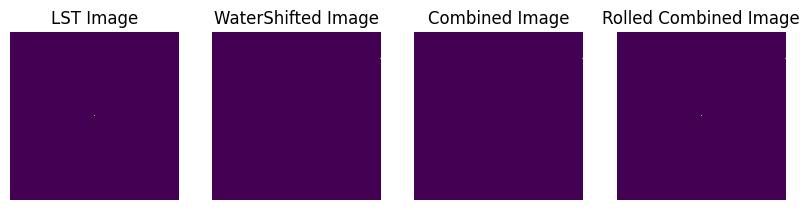

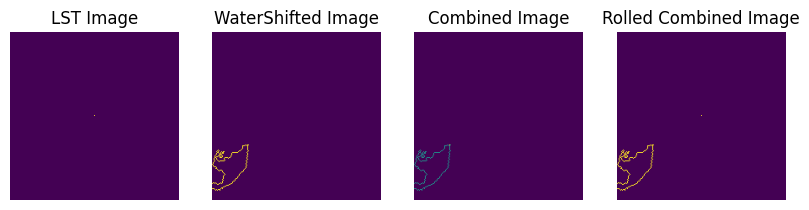

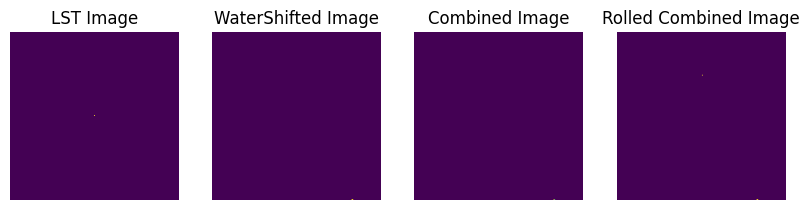

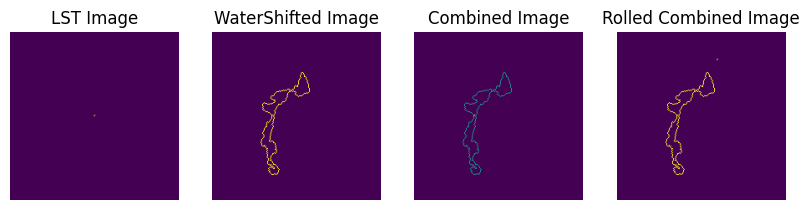

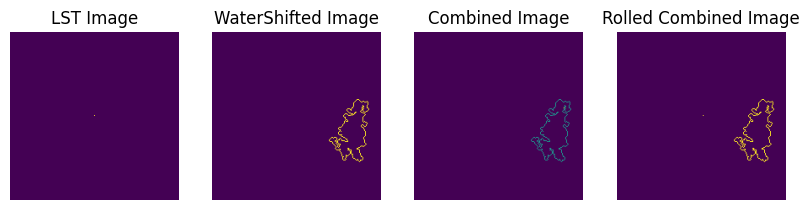

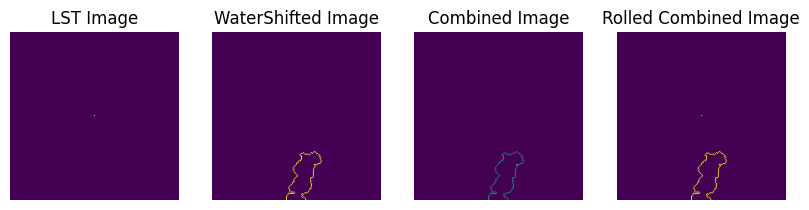

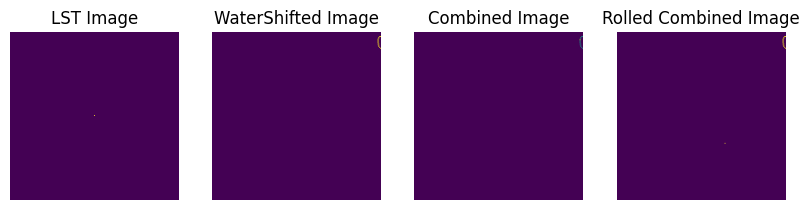

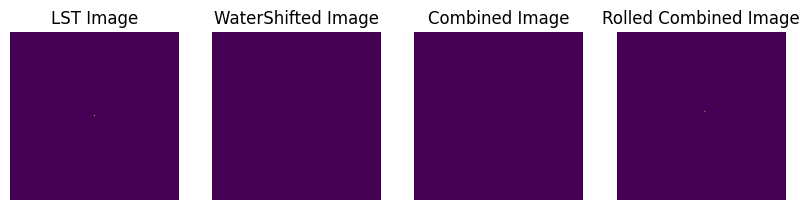

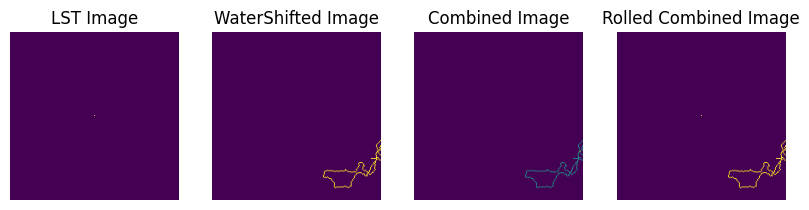

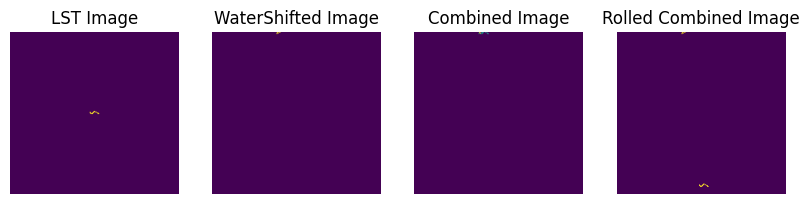

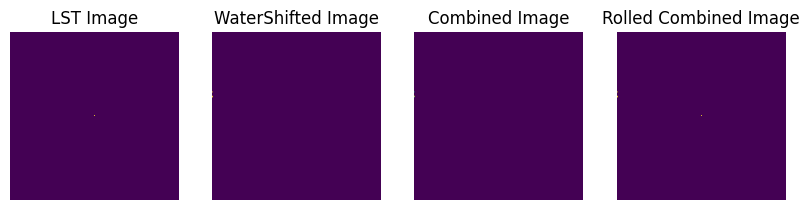

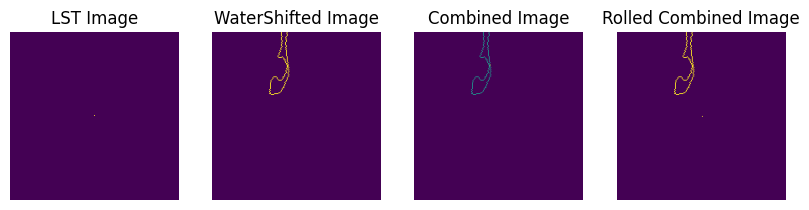

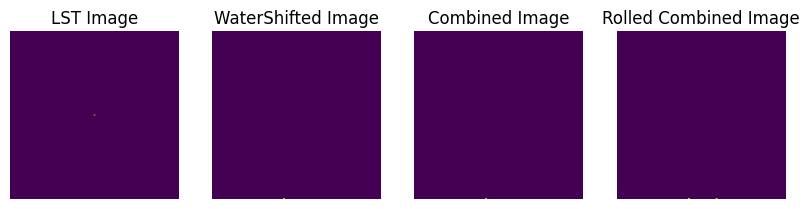

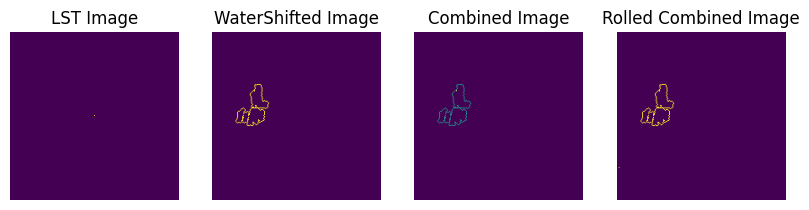

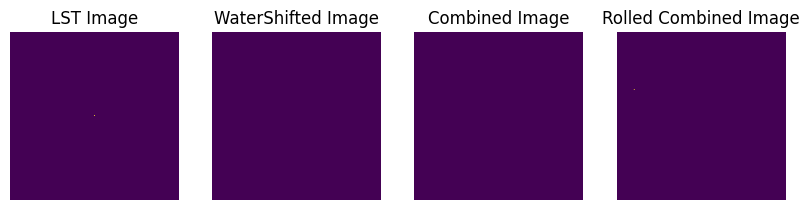

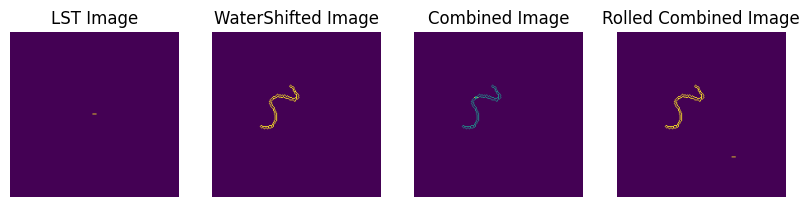

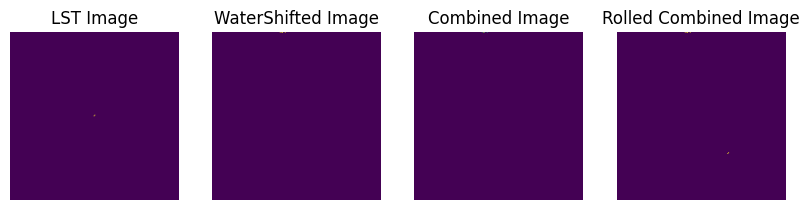

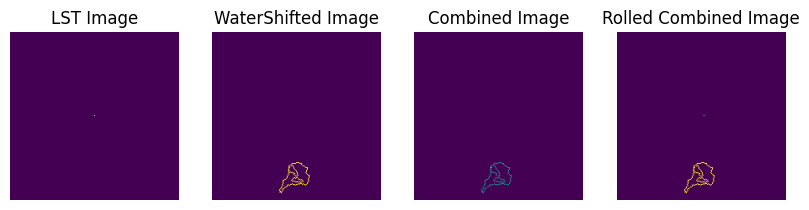

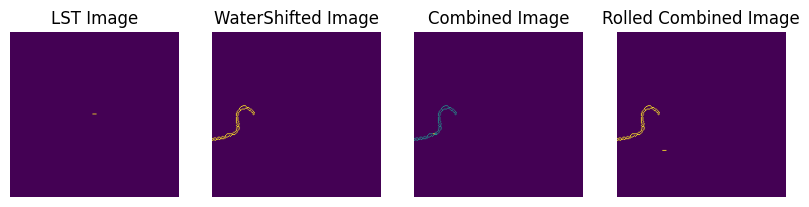

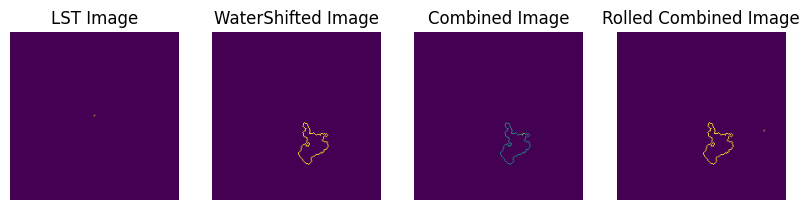

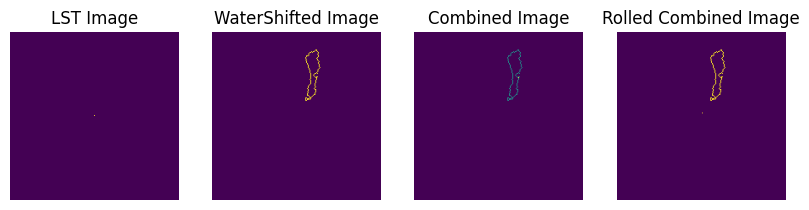

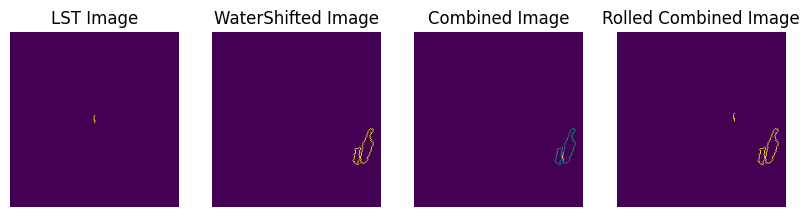

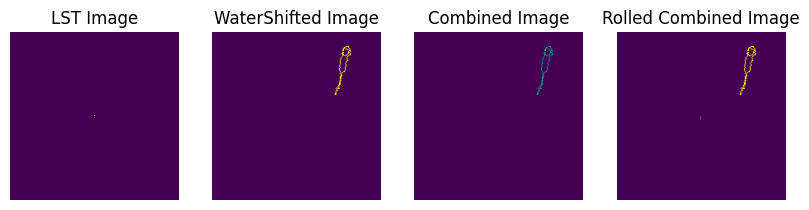

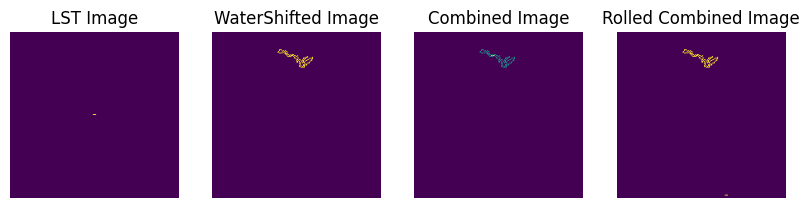

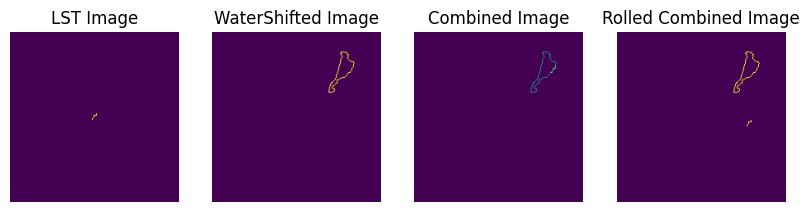

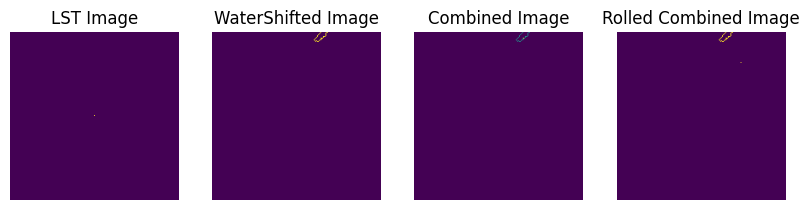

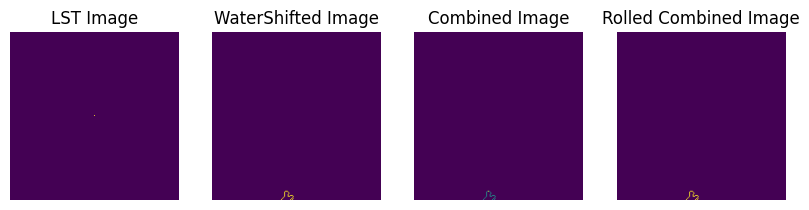

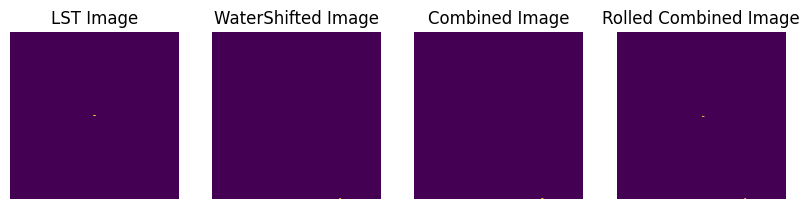

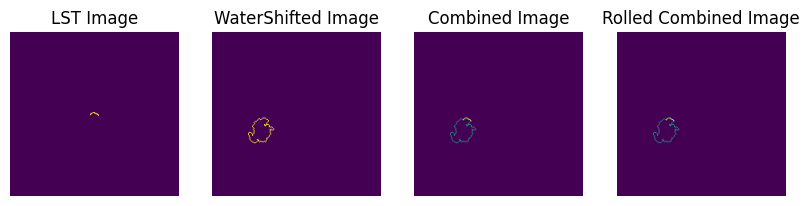

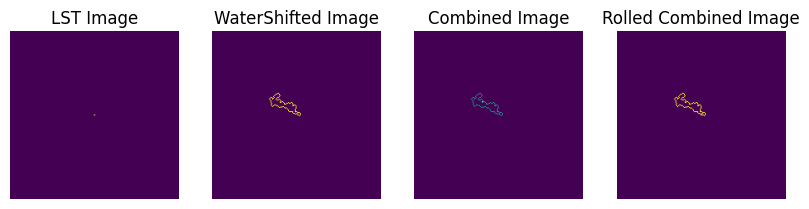

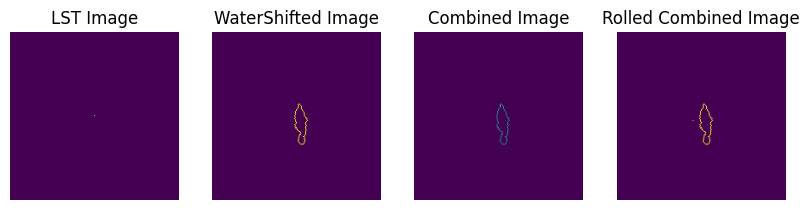

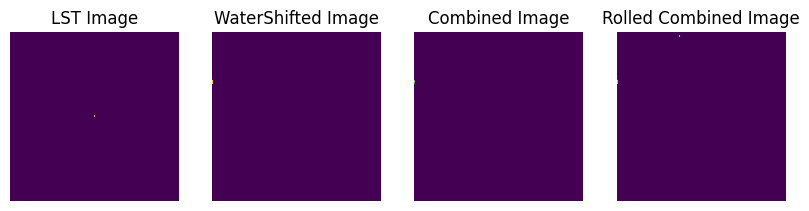

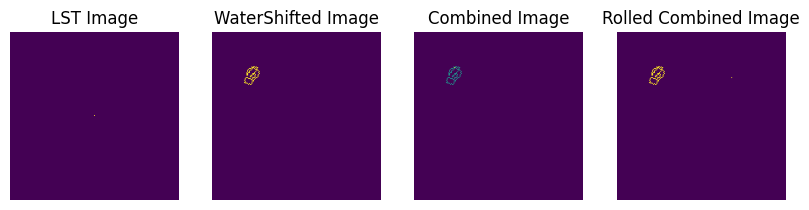

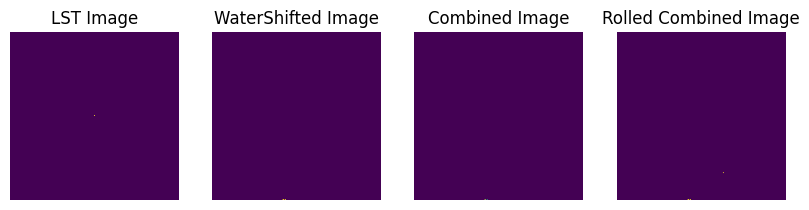

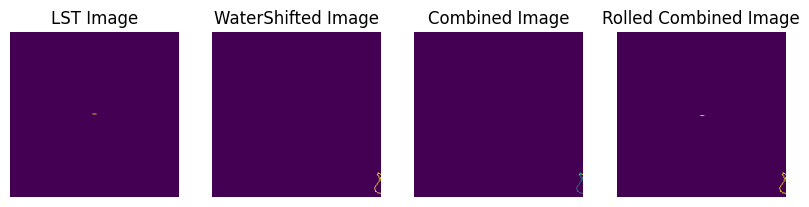

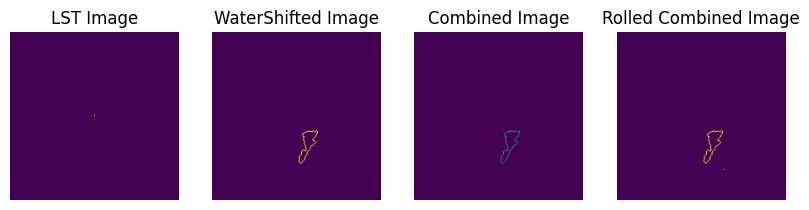

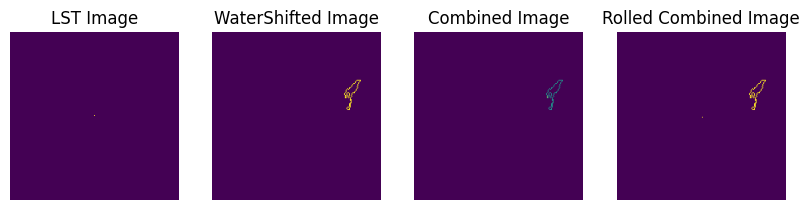

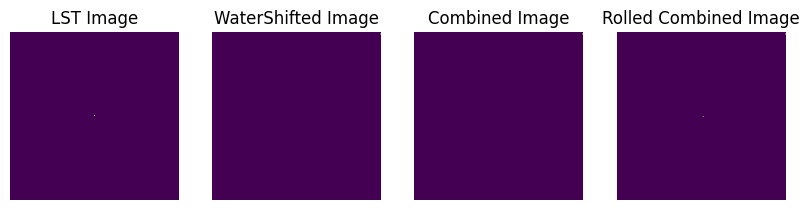

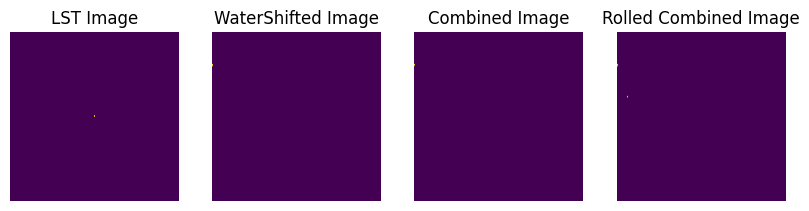

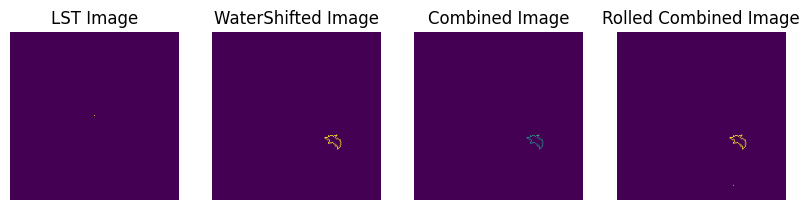

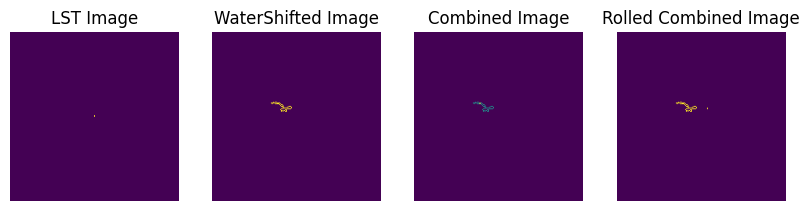

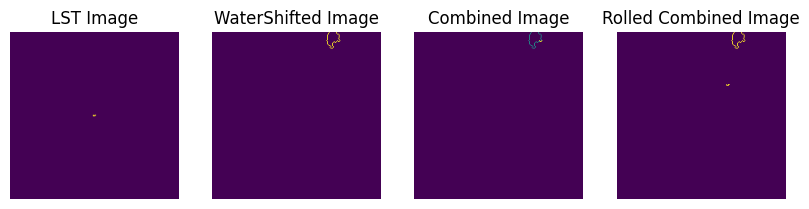

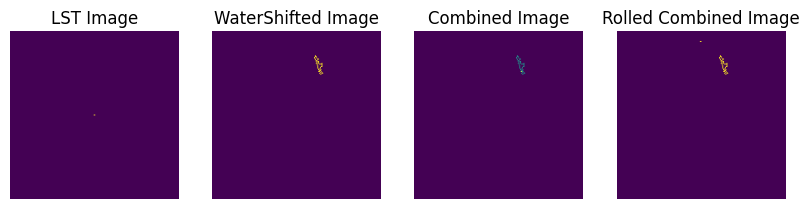

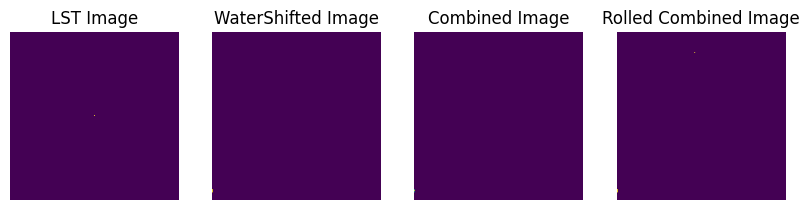

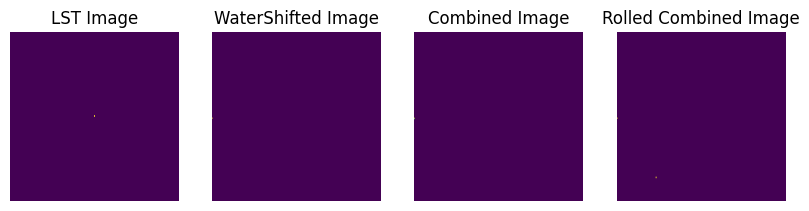

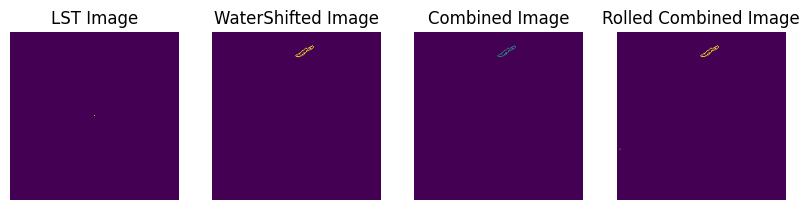

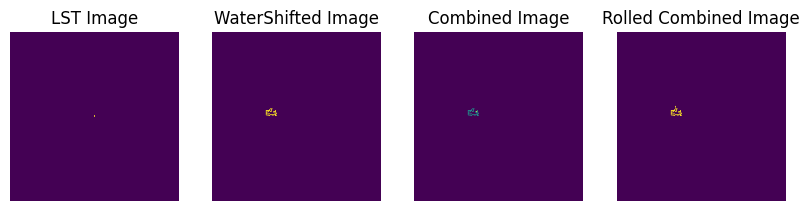

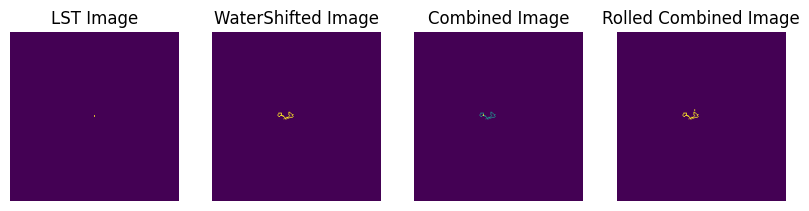

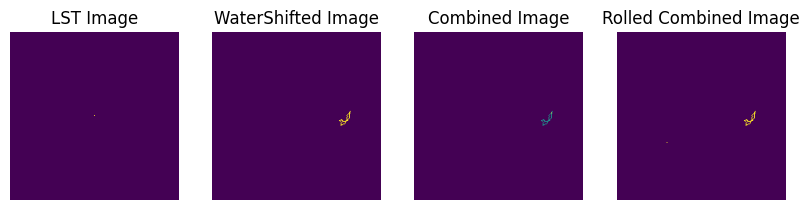

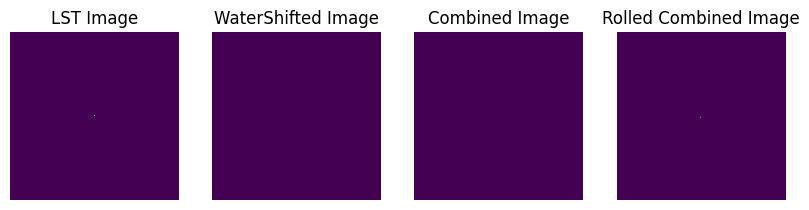

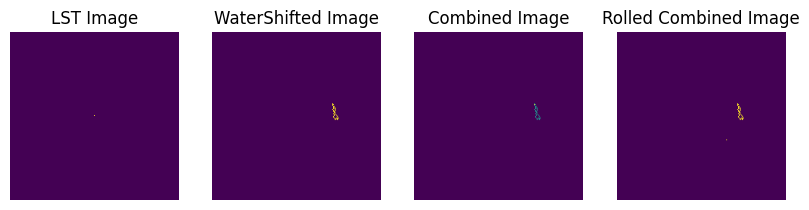

Shift aborted due to limited LST Shores 

Shift aborted due to limited LST Shores 



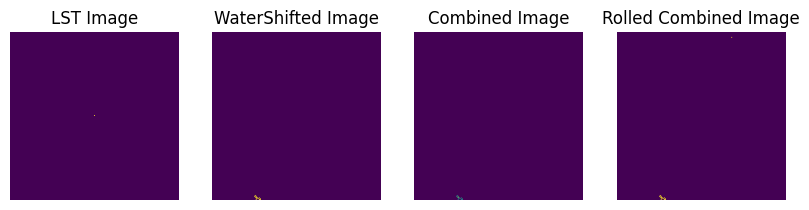

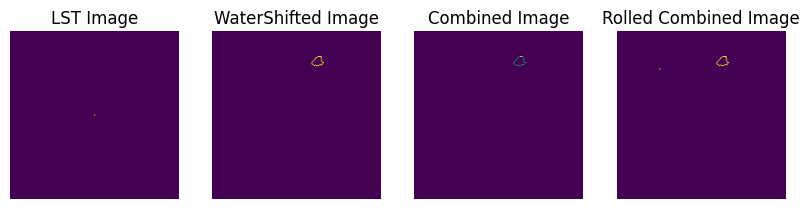

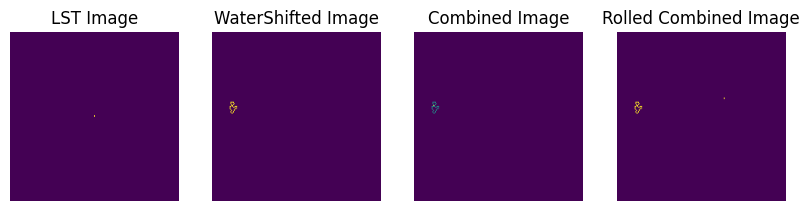

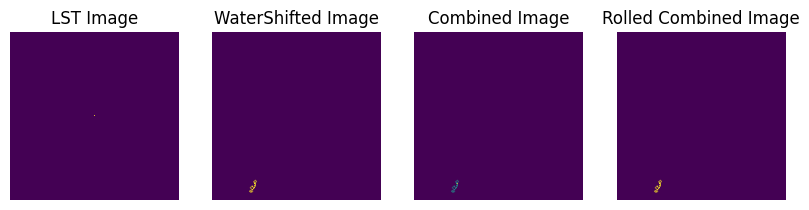

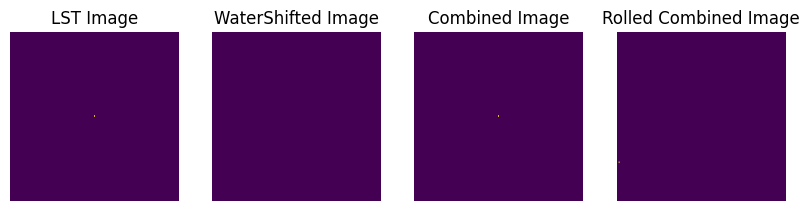

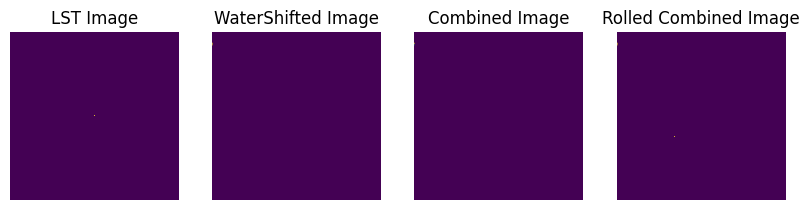

Shift aborted due to limited LST Shores 

Shift aborted due to limited LST Shores 



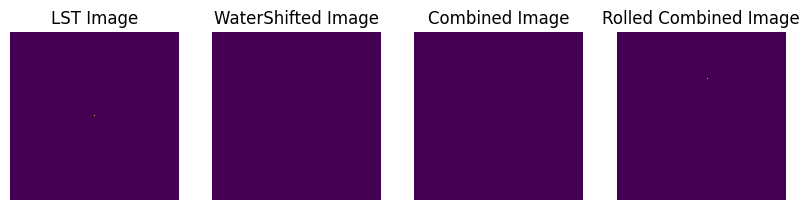

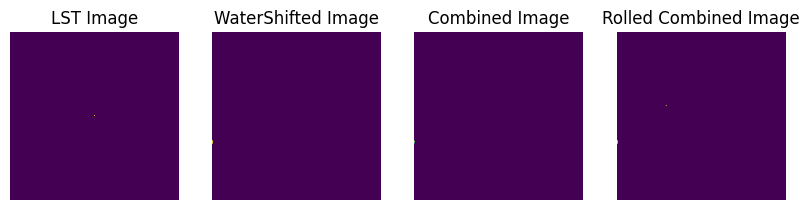

Shift aborted due to limited LST Shores 



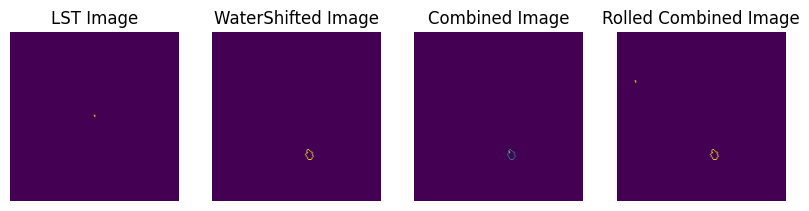

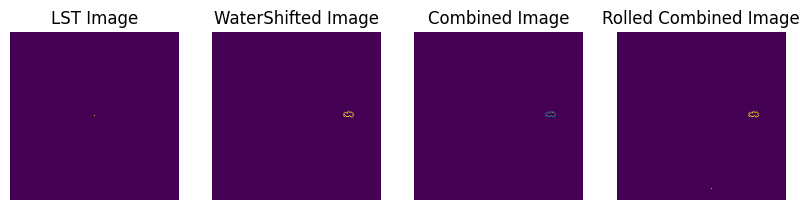

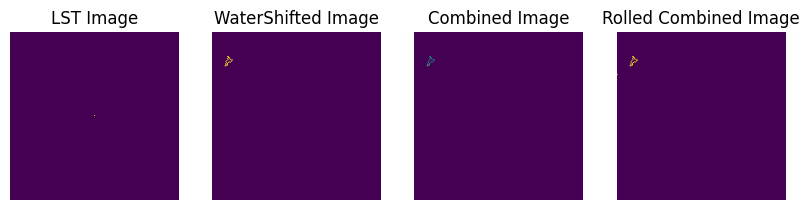

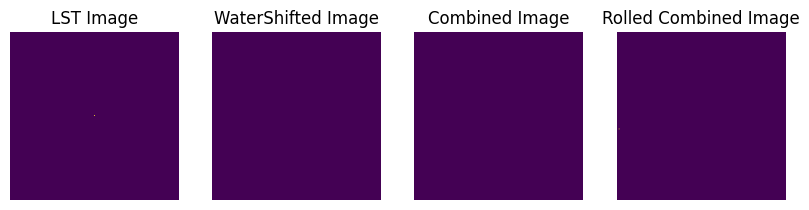

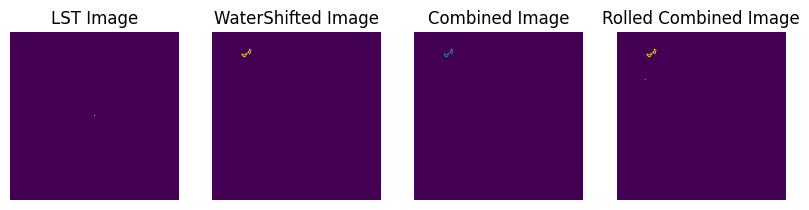

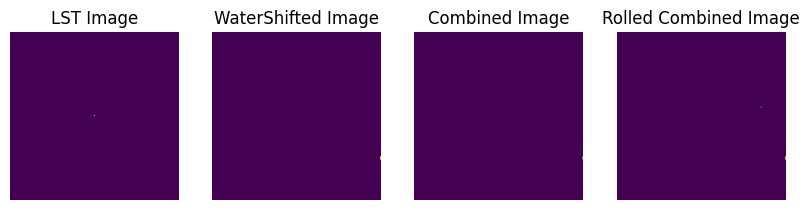

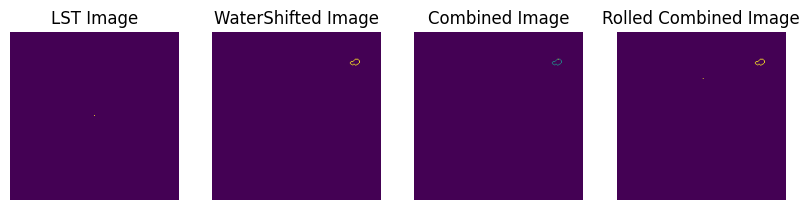

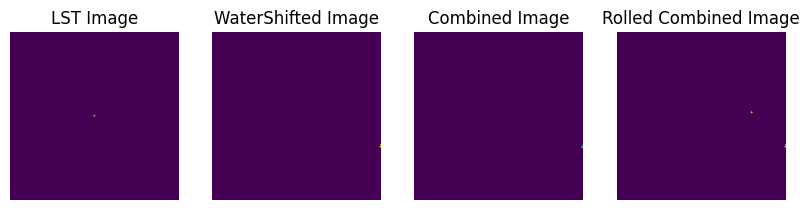

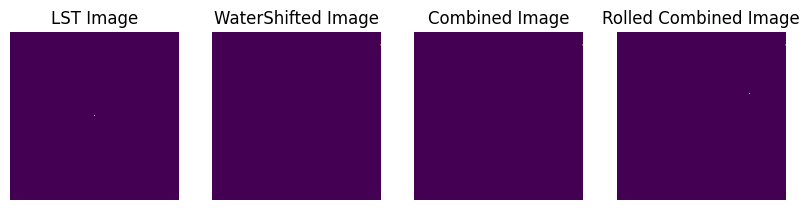

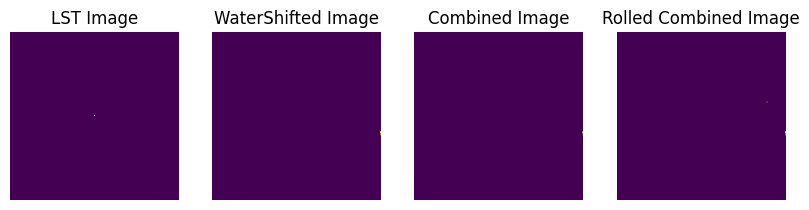

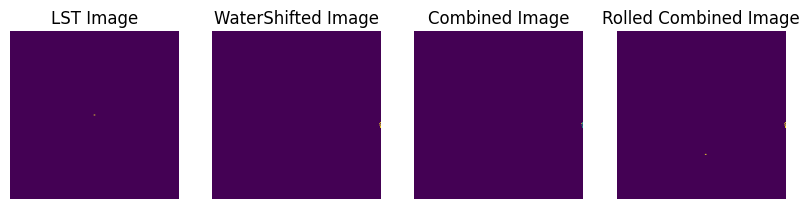

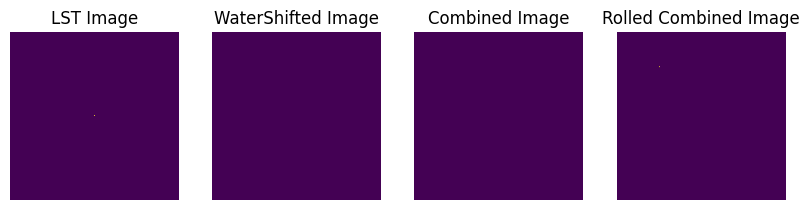

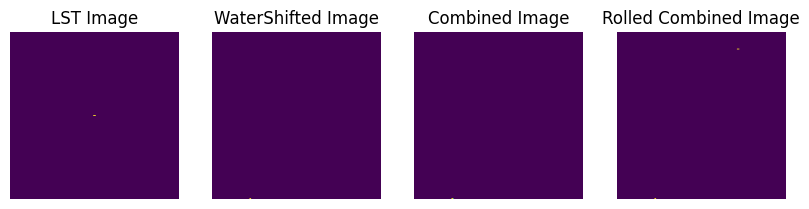

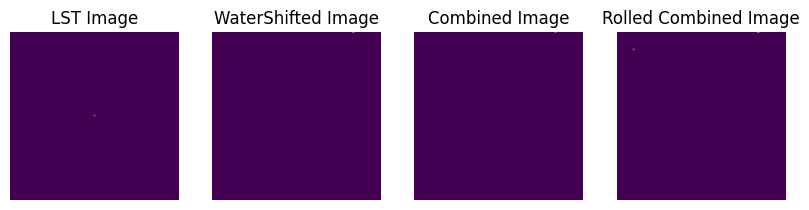

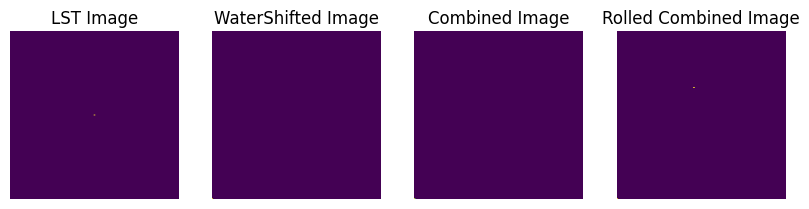

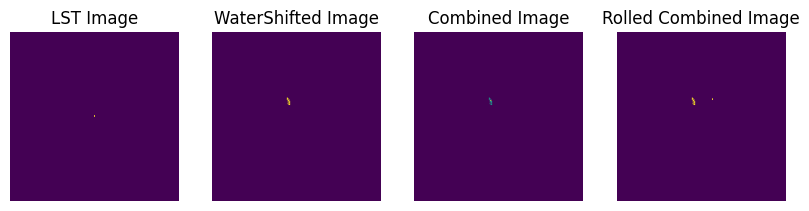

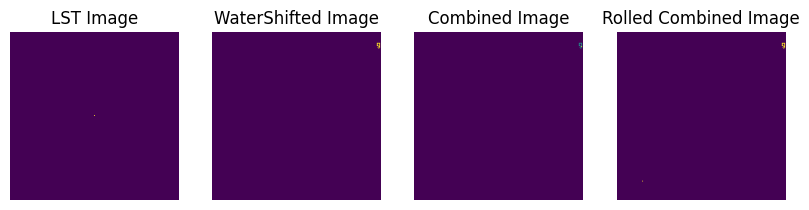

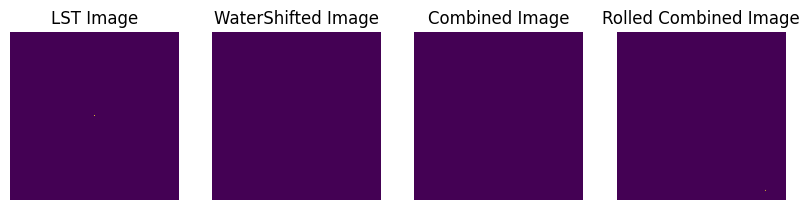

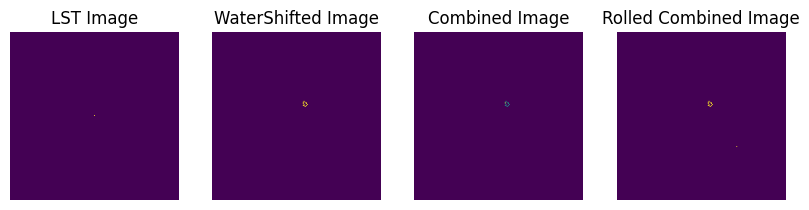

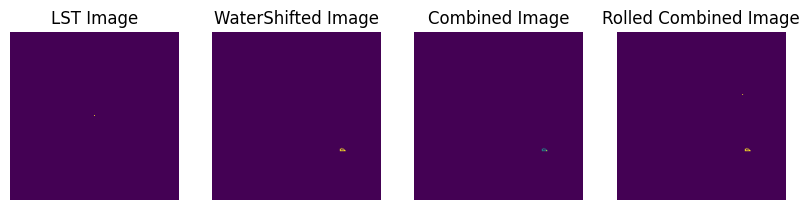

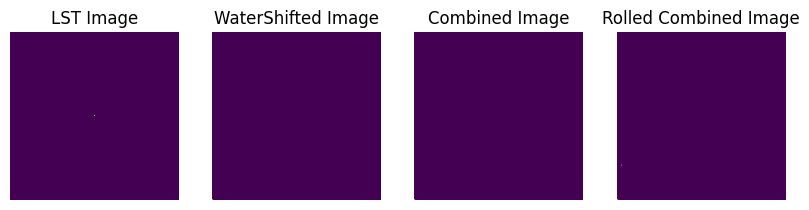

Shift aborted due to limited LST Shores 



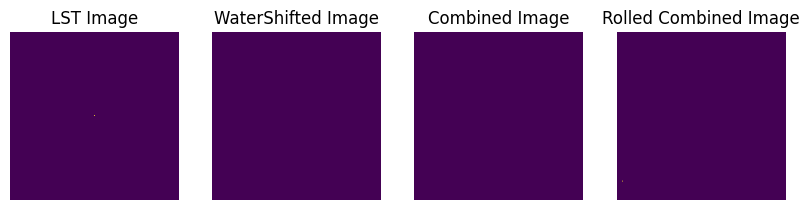

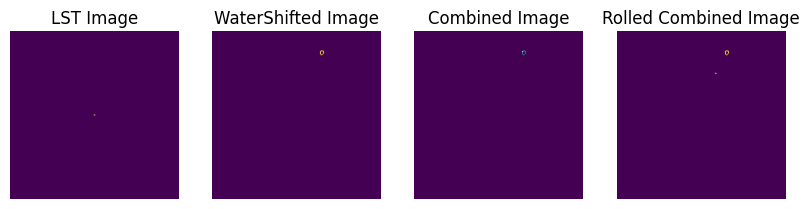

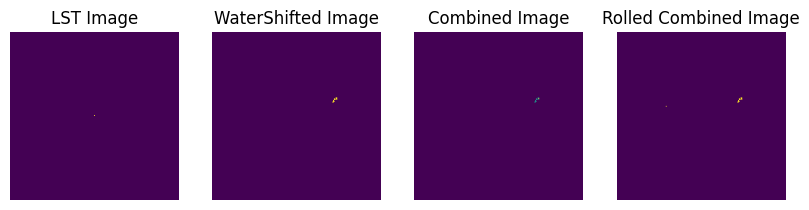

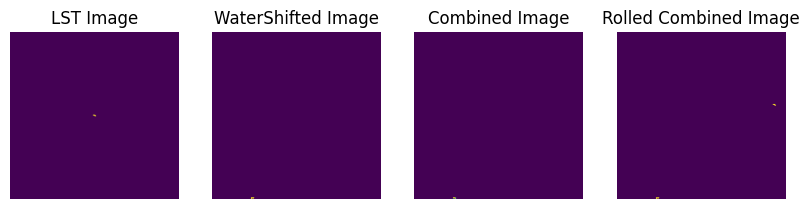

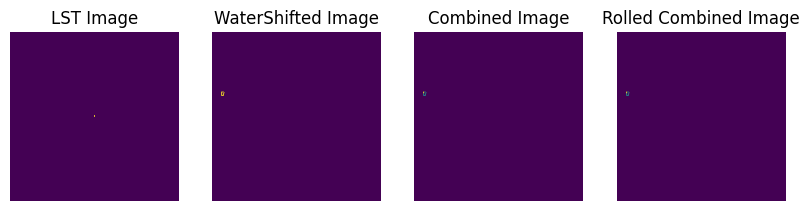

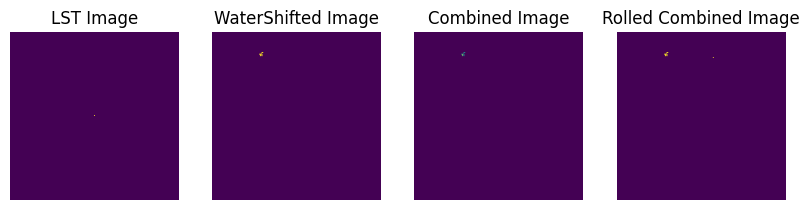

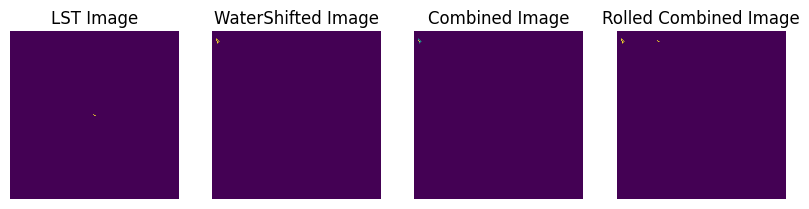

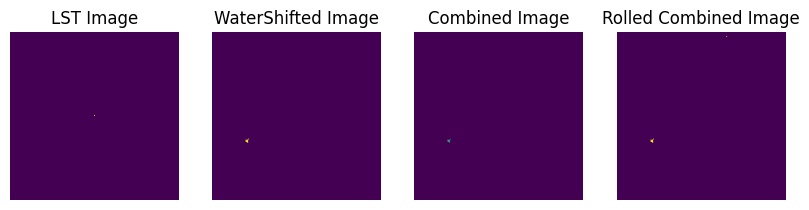

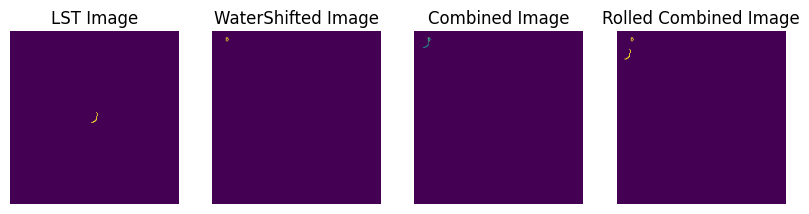

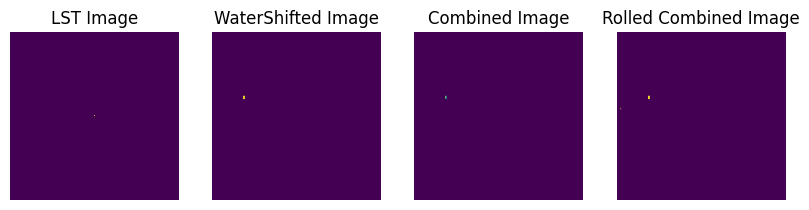

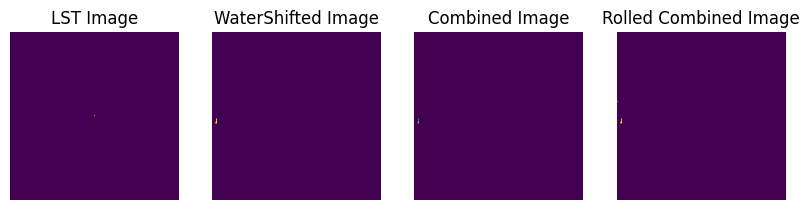

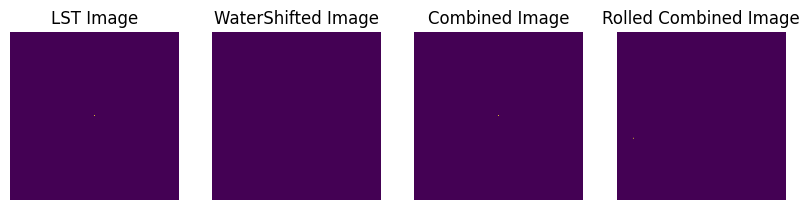

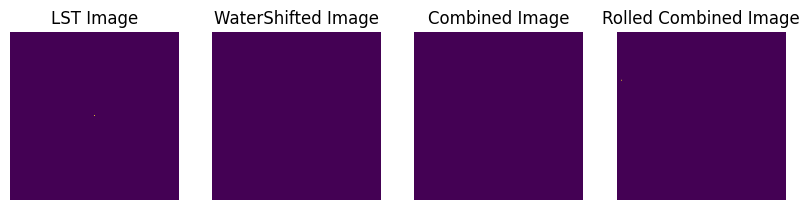

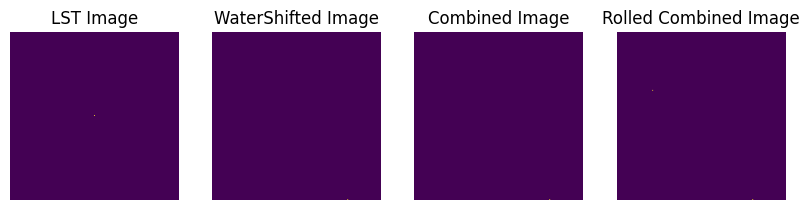

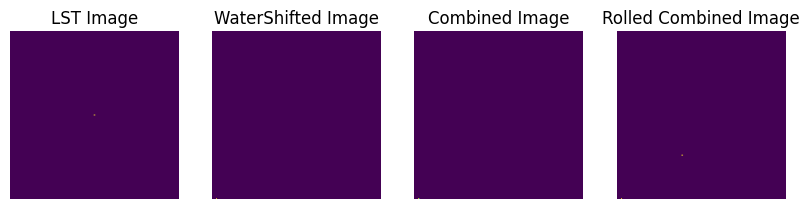

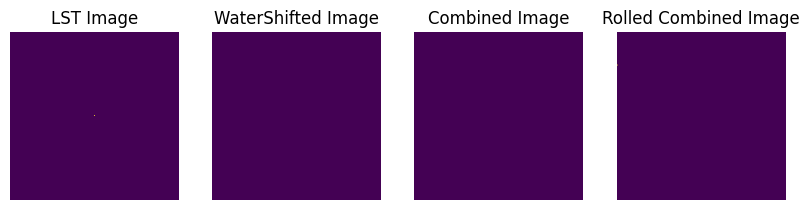

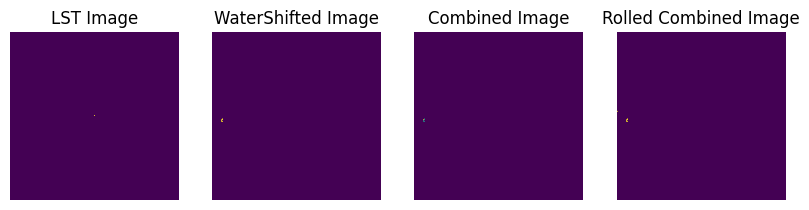

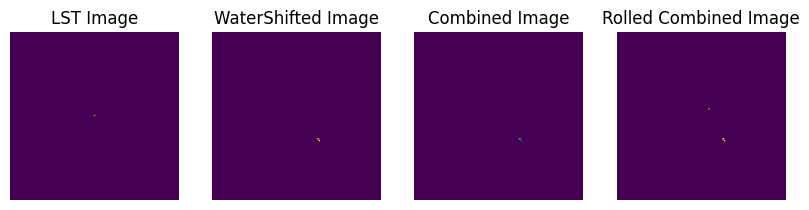

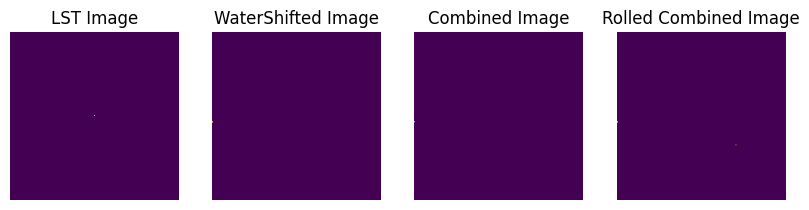

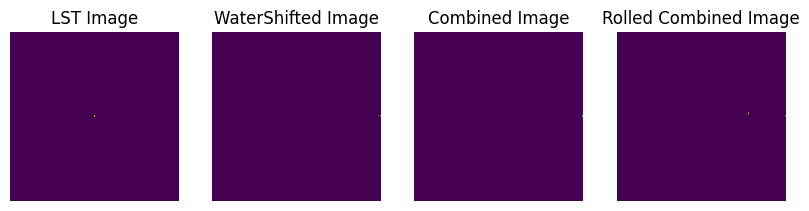

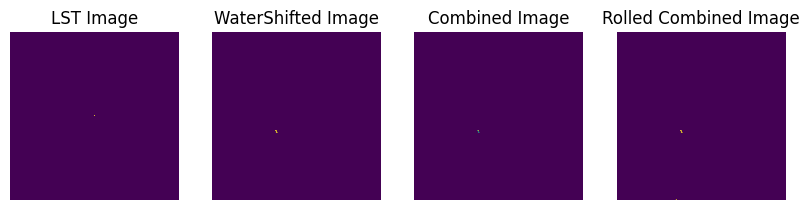

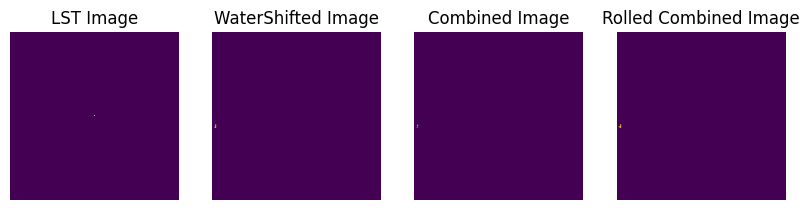

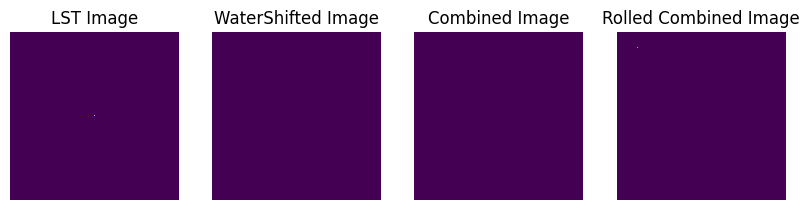

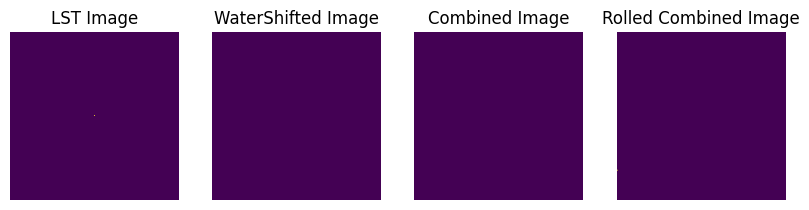

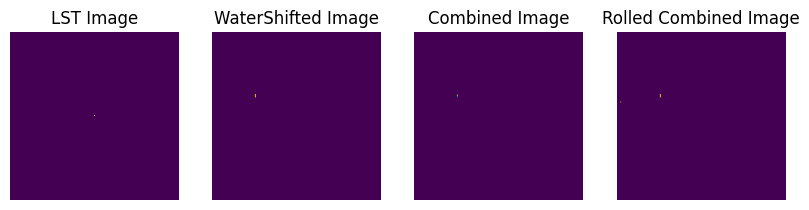

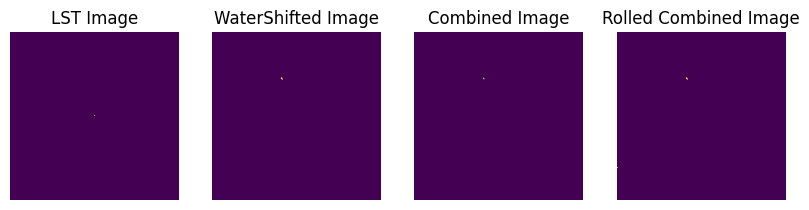

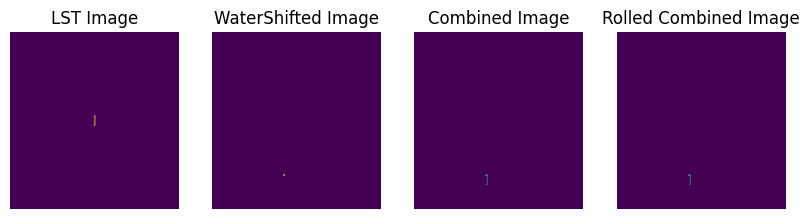

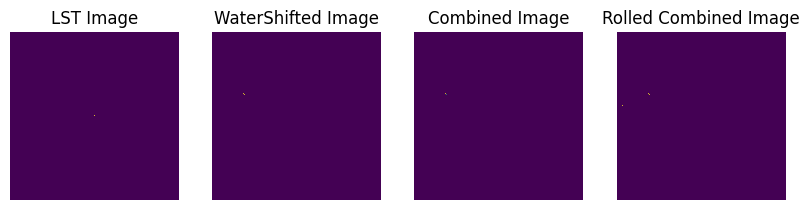

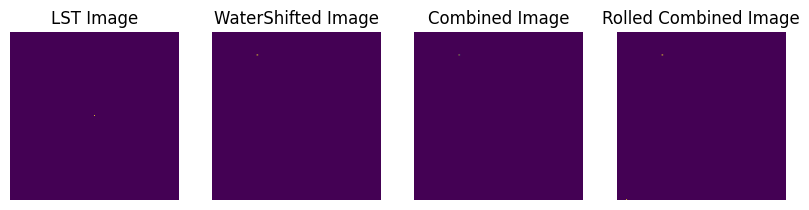

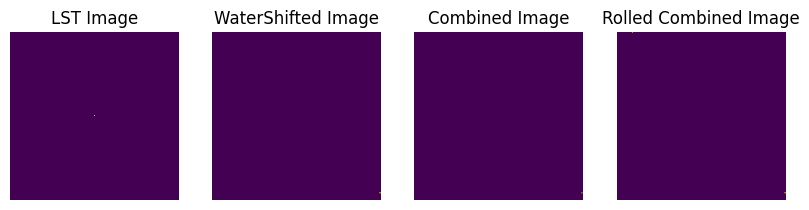

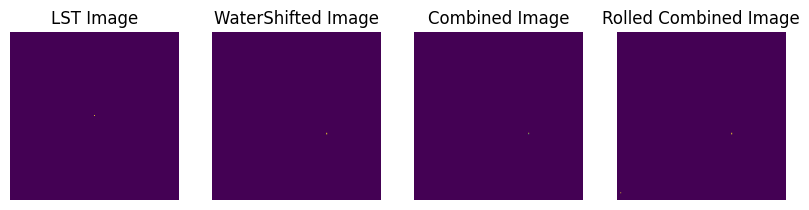

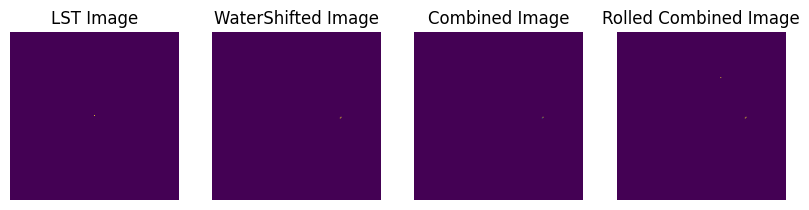

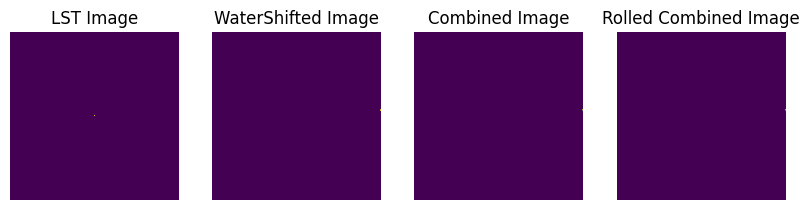

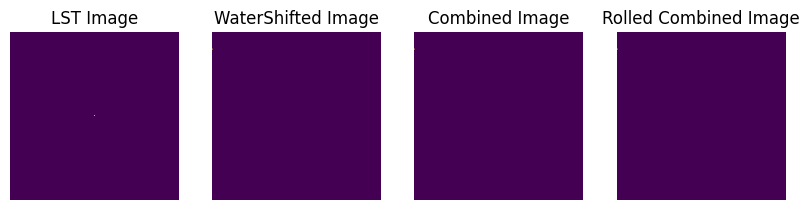

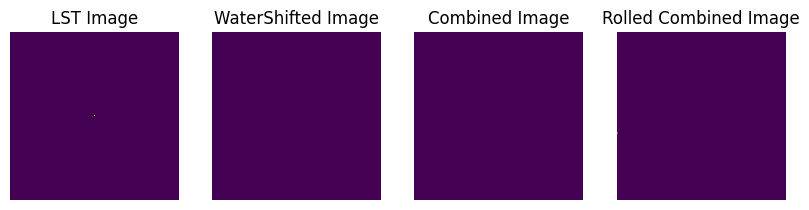

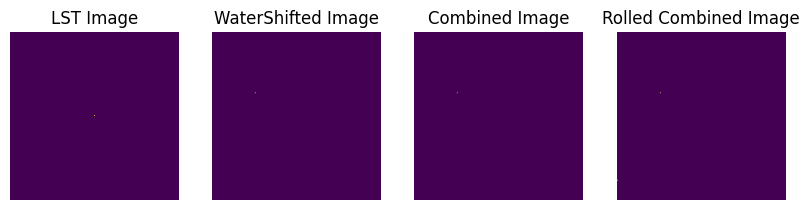

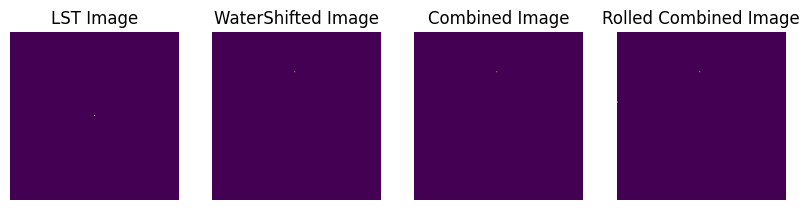

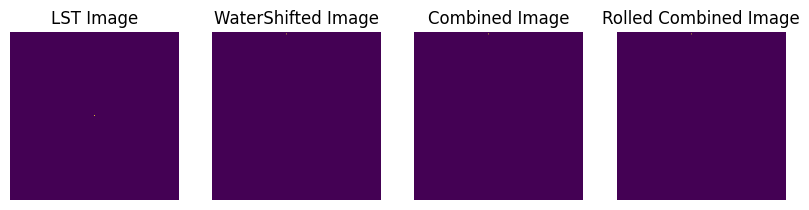

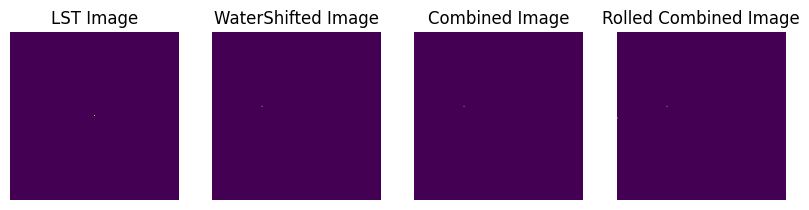

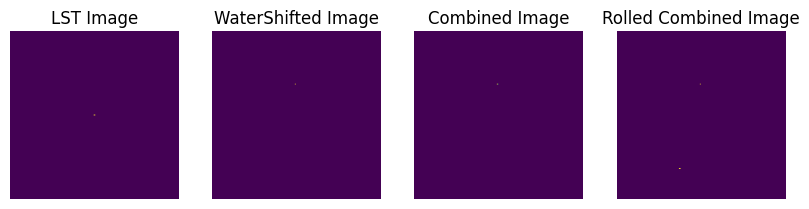

In [ ]:
## ============================================================
## Step 5: Iterate Over Shoreline Segments and Acquire Candidate Shifts
## ============================================================
## For each significant shoreline component (sorted by area), this loop:
##   1. Isolates the individual water mask shoreline segment.
##   2. Clips the LST edge image to that segment's bounding box.
##   3. Ranks LST edge lines by pixel length and selects the top N:
##      - If the longest line is >= 2x the second longest AND >= 50,000 px,
##        only the top 5 lines are used (dominant single feature).
##      - Otherwise, the top 100 lines are used (multiple comparable features).
##   4. For each selected LST edge line, detects its endpoints and
##      finds the pixel shift (dx, dy) that best aligns it to the
##      water mask shoreline via MatchingOverlay.
##   5. The best per-segment shift is determined by testing all
##      candidate (dx, dy) pairs together against the full shoreline.
## ============================================================

for Labeled_line in sorted_indecies:
    if Labeled_line == 0:  # Skip background label
        continue

    # Isolate this individual shoreline component
    Isolated_Shore = (Mapped_Lines2 == Labeled_line).astype(np.uint8)

    # Clip LST edge image to this shoreline's bounding box
    [Indv_Water_Line, Indv_Eco_Line, _, _, _, _] = Best_Line_Eco(
        0, Isolated_Shore, Blank, Distinct_Line_Selection, 100, 1
    )

    # Sort LST edge lines within the clip by pixel length
    Sorted_Table, Labeled_ECOSTRESS_Image = Sorted_Longest_Lines(Indv_Eco_Line)

    Top_2 = Sorted_Table.iloc[:2, -1].values
    if Top_2.size < 2:
        print("Shift aborted due to limited LST Shores \n")
        continue

    First_Row  = Top_2[0]
    Second_Row = Top_2[1]

    # Select top 5 or top 100 lines depending on dominance of longest line
    if First_Row >= (Second_Row * 2) and First_Row >= 50000:
        Index_values = ((Sorted_Table.head(5))['label']).to_list()
    else:
        Index_values = ((Sorted_Table.head(100))['label']).to_list()

    Sorted_Lines_Map = np.isin(Labeled_ECOSTRESS_Image, test_elements=Index_values)
    Newly_Labeled    = measure.label(Sorted_Lines_Map, connectivity=2)

    Temp_Matching_Stats = []

    # --- Per-line shift acquisition ---
    for i in range(0, len(Index_values)):
        [Eco_Line, Water_Line, _, Col_length, Row_length, Actual_Index] = Best_Line_Eco(
            i, Newly_Labeled, Blank, Indv_Water_Line, 100, 1
        )

        Skeleton_image, Endpoints = End_Points(Eco_Line)

        # Only use lines with 6 or fewer endpoints (avoids highly branched, noisy features)
        if len(Endpoints) <= 6:
            Skeleton_image = morphology.isotropic_dilation(Skeleton_image, radius=1)  # Thicken for better overlap

            [Col_Shift, Row_Shift, Ratio, _] = MatchingOverlay(Skeleton_image, Water_Line, 100, Endpoints)

            # Store shift with a quality score: ratio² × bounding box area (rewards large, well-aligned lines)
            Temp_Matching_Stats.append([
                Col_Shift, Row_Shift,
                (Ratio * Ratio) * Col_length * Row_length,
                (Actual_Index + 1)  # +1 corrects label index offset
            ])

    # --- Combine top candidate shifts for this shoreline segment ---
    Temp_Sorted_Matching_Stats = sorted(Temp_Matching_Stats, key=lambda x: x[2], reverse=True)

    Temp_X_Shifts    = [i[0] for i in Temp_Sorted_Matching_Stats]
    Temp_Y_Shifts    = [i[1] for i in Temp_Sorted_Matching_Stats]
    Temp_Best_Indexes = [i[3] for i in Temp_Sorted_Matching_Stats]

    Temp_Shift_Coordinates = np.column_stack((Temp_X_Shifts, Temp_Y_Shifts))

    # Combine the top-ranked LST lines into a single binary image and dilate
    Temp_Top_Lines     = np.isin(Newly_Labeled, test_elements=Temp_Best_Indexes)
    Temp_Buffered_Lines = morphology.isotropic_dilation(Temp_Top_Lines, radius=1)

    # Evaluate all candidate shifts together and select the best for this segment
    [Temp_X_Shift, Temp_Y_Shift, _, _, _] = Matching_Shift(
        Temp_Shift_Coordinates, Temp_Buffered_Lines, Indv_Water_Line
    )

    Main_Matching_Stats.append([Temp_X_Shift, Temp_Y_Shift])

    ## ============================================================
    ## Optional: Per-line visualization (for debugging/inspection)
    ## ============================================================
    ## The block below generates 4-panel figures for each shoreline
    ## segment showing the original and shifted LST overlaid on the
    ## water mask. It is useful for verifying alignment but will
    ## produce one figure per segment iteration.
    ## To activate: remove the surrounding comment block and run.
    ## To stop early: click the square Stop button in the cell toolbar.
    ## ============================================================

    Image    = np.roll(Eco_Line, (Col_Shift, Row_Shift), axis=(1, 0))
    Combined = Image + Water_Line

    Image2    = np.roll(Eco_Line, (Temp_X_Shift, Temp_Y_Shift), axis=(1, 0))
    Combined2 = Image2 + Water_Line

    fig, axs = plt.subplots(1, 4, figsize=(10, 10))
    axs[0].imshow(Eco_Line);  axs[0].set_title('LST Edge');           axs[0].axis('off')
    axs[1].imshow(Water_Line); axs[1].set_title('Water Shoreline');   axs[1].axis('off')
    axs[2].imshow(Combined);  axs[2].set_title('Unshifted Overlay');  axs[2].axis('off')
    axs[3].imshow(Combined2); axs[3].set_title('Shifted Overlay');    axs[3].axis('off')
    plt.show()


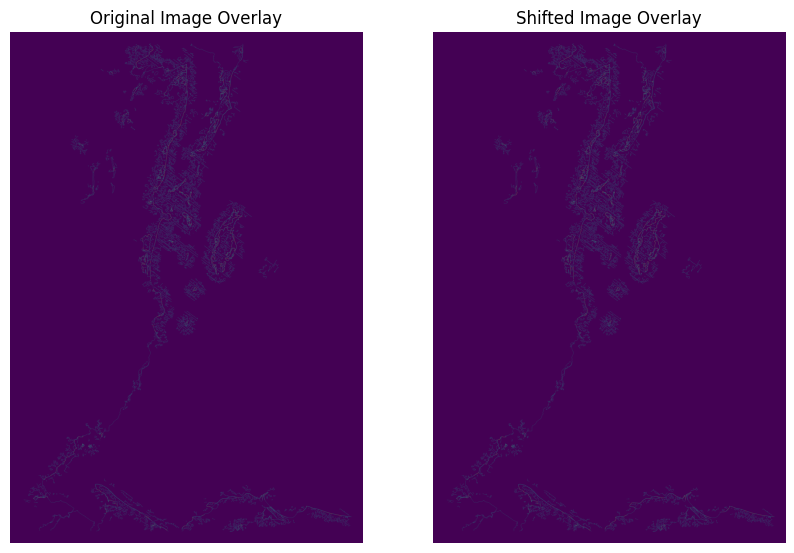

Final Shift
x-shift is 1 

y-shift is 1 



In [ ]:
## ============================================================
## Step 6: Determine Final Scene-Level Pixel Shift
## ============================================================
## All per-segment candidate shifts are tested together against
## the full clipped water mask shoreline to determine the single
## best (dx, dy) correction for the entire scene.
## ============================================================

# Collect all per-segment shift candidates
Main_X_Shifts = [i[0] for i in Main_Matching_Stats]
Main_Y_Shifts = [i[1] for i in Main_Matching_Stats]

# Dilate the full LST edge image to improve overlap sensitivity
Main_Buffered_Lines = morphology.isotropic_dilation(Distinct_Line_Selection, radius=1)

Main_Shift_Coordinates = np.column_stack((Main_X_Shifts, Main_Y_Shifts))

# Select the shift that maximizes overlap with the water mask across all segments
[Main_X_Shift, Main_Y_Shift, _, _, _] = Matching_Shift(
    Main_Shift_Coordinates, Main_Buffered_Lines, Clip_Water
)

## --- Visualize the final correction ---
Shifted_Image = np.roll(Distinct_Line_Selection, (Main_X_Shift, Main_Y_Shift), axis=(1, 0))
Pre_Shifted   = Distinct_Line_Selection + Clip_Water  # Before correction
Total_Image   = Shifted_Image + Clip_Water             # After correction

fig, axs = plt.subplots(1, 2, figsize=(10, 10))
axs[0].imshow(Pre_Shifted); axs[0].set_title('Before Correction'); axs[0].axis('off')
axs[1].imshow(Total_Image); axs[1].set_title('After Correction');  axs[1].axis('off')
plt.show()

print('Final Shift')
print(f'x-shift is {Main_X_Shift} \n')
print(f'y-shift is {Main_Y_Shift} \n')


In [ ]:
## ============================================================
## Step 7: Apply Pixel Shift and Save Corrected GeoTIFF
## ============================================================
## The geolocation correction is applied by updating the GeoTransform
## of the original GeoTIFF. The pixel shift (in pixel units) is
## converted to projected coordinate units using the pixel resolution
## from the original GeoTransform, then added to the origin coordinates.
##
## Output is written to a 'Geolocated LST' subfolder within LST_Folder's
## parent directory, prefixed with 'Shifted_'.
## ============================================================

import os
from osgeo import gdal

# Create output folder (no error if it already exists)
New_Folder = "/content/drive/MyDrive/<YOUR_PROJECT_FOLDER>/ECOSTRESS Tifs/Geolocated LST"
os.makedirs(New_Folder, exist_ok=True)

# Open the original LST GeoTIFF
Eco_Main = gdal.Open(EcoFile)
driver = gdal.GetDriverByName('GTiff')

# Build the output filename by prepending 'Shifted_' to the original basename
Eco_FileName = os.path.basename(EcoFile)
New_Name = os.path.join(New_Folder, 'Shifted_' + Eco_FileName)

# Copy the original file to preserve all metadata, bands, and projection
New_File = driver.CreateCopy(New_Name, Eco_Main, strict=0)
New_File = None  # Close immediately; we will reopen for update

# Reopen the copy in update mode to modify the GeoTransform
Shift_File = gdal.Open(New_Name, gdal.GA_Update)

# Unpack the original GeoTransform
# Format: (x_origin, x_res, x_rotation, y_origin, y_rotation, y_res)
x_tl, x_res, dx_dy, y_tl, dy_dx, y_res = Shift_File.GetGeoTransform()

# Convert pixel shift to projected coordinate offset
shift_x = Main_X_Shift * x_res
shift_y = Main_Y_Shift * y_res

# Apply corrected origin to GeoTransform and flush to disk
gt_update = (x_tl + shift_x, x_res, dx_dy, y_tl + shift_y, dy_dx, y_res)
Shift_File.SetGeoTransform(gt_update)
Shift_File.FlushCache()

print(f'Corrected file saved as: {New_Name}')
print(f'Applied shift: {Main_X_Shift} pixels horizontally, {Main_Y_Shift} pixels vertically')

# Close all GDAL file handles
Eco_Main   = None
Shift_File = None


Shifted file saved as: /content/drive/MyDrive/Coral PDRDF/ECOSTRESS Tifs/Geolocated LST/Shifted_ECO_L2T_LSTE.002_LST_doy2023205200541_aid0001_16N.tif
Applied shift: 1 pixels horizontally, 1 pixels vertically
